# Modularity Maximization vs. Stochastic Block Model on the Left oviIN Inputs (V3)

### Dataset: FAFB FlyWire v783

This notebook asks: **does the community structure in the oviIN input subconnectome depend on the method used to detect it?** Two independent methods — one based on modularity optimization (RenEEL) and one based on statistical inference (degree-corrected SBM) — are applied to the same network. If they find the same communities, the structure is robust and likely reflects real biology.

**Section 0** — Environment setup (run once, restart, then skip).

**Section 1** — Data loading: identify the left oviIN, extract its input subconnectome, fetch per-synapse xyz coordinates, and fetch the neuron skeleton for visualization.

**Section 2** — Modularity maximization using RenEEL at chi=0. Plots show synapses on the oviIN skeleton in anterior view (X-Z), matching the Hemibrain oviIN orientation.

**Section 3** — Degree-corrected SBM via graspologic. Same skeleton-overlaid anterior view plots.

**Section 4** — Comparison using pairwise Jaccard similarity and containment scores.

**Section 5** — Chi-sweep: RenEEL at multiple resolutions to test hierarchical nesting.

**Section 6** — Merge-based coarsening: coarsen RenEEL to match the SBM's scale.

**Section 7** — Biological characterization: NT type, neuropil, cell class per module and block.

**Section 8** — SBM variability: 10 runs with pairwise ARI to assess partition stability.

*Source: Gutierrez Lab, Barnard College. Data from FlyWire (Dorkenwald et al., 2024).*

---
# Section 0: Environment Setup

Graspologic requires `numpy < 2.0` and skeleton fetching uses `navis` and `fafbseg`. **Run once, restart runtime, then skip to Section 1.**

In [1]:
# ──────────────────────────────────────────────────────────
# CELL 0.1 — Install dependencies
# ──────────────────────────────────────────────────────────
!pip install "numpy<2.0,>=1.24" "pandas>=1.5,<3.0" graspologic caveclient -q
!pip install navis fafbseg cloud-volume -q
print("Done. Restart runtime, then skip to Section 1.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 917.8/917.8 kB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.5/416.5 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

---
# Section 1: Data Loading

This section loads the FAFB FlyWire v783 dataset, identifies the left oviIN, and extracts the **input subconnectome** — all neurons that provide synaptic input to the oviIN and all directed connections among them. We also fetch per-synapse xyz coordinates and the oviIN neuron skeleton for visualization.

## 1.1 Imports

In [1]:
# ──────────────────────────────────────────────────────────
# CELL 1.1 — Imports
# ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from collections import Counter
import subprocess, sys, os, re, string, random, json, pathlib, time
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive, userdata
drive.mount('/content/drive', force_remount=True)
print("Imports complete.")

Mounted at /content/drive
Imports complete.


## 1.2 Load FAFB tables

Three CSV files are needed: the connections edge list, cell type annotations, and classification (for side determination). Large files are loaded with retry logic to handle intermittent Drive disconnections.

In [2]:
# ──────────────────────────────────────────────────────────
# CELL 1.2 — Load FAFB tables with retry logic
# ──────────────────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/Barnard Drosophila/FAFB/Data_Files/'

def read_csv_with_retry(path, max_retries=3, wait=5):
    for attempt in range(max_retries):
        try:
            return pd.read_csv(path)
        except OSError as e:
            if attempt < max_retries - 1:
                print(f"  Read failed ({e}). Retrying in {wait}s...")
                time.sleep(wait)
                drive.mount('/content/drive', force_remount=True)
            else:
                raise

connections = read_csv_with_retry(DATA_DIR + 'connections_princeton.csv')
cell_types = read_csv_with_retry(DATA_DIR + 'consolidated_cell_types.csv')
classification = read_csv_with_retry(DATA_DIR + 'classification.csv')
print(f"connections: {len(connections):,}, cell_types: {len(cell_types):,}, classification: {len(classification):,}")

# ── Sanity checks ──
assert list(connections.columns) == ['pre_root_id','post_root_id','neuropil','syn_count','nt_type']
assert 'primary_type' in cell_types.columns and 'side' in classification.columns
print("✓ Schema checks passed.")

connections: 5,342,446, cell_types: 138,327, classification: 139,255
✓ Schema checks passed.


## 1.3 Identify the left oviIN

In [3]:
# ──────────────────────────────────────────────────────────
# CELL 1.3 — Find the left oviIN root_id
# ──────────────────────────────────────────────────────────
ovi = cell_types[cell_types['primary_type'] == 'oviIN']
ovi_full = ovi.merge(classification[['root_id', 'side']], on='root_id', how='left')
print("oviIN neurons in FAFB:")
print(ovi_full[['root_id', 'primary_type', 'side']].to_string(index=False))

oviIN_left_id = ovi_full.loc[ovi_full['side'] == 'left', 'root_id'].iloc[0]
print(f"\nLeft oviIN root_id: {oviIN_left_id}")
assert (ovi_full['side'] == 'left').sum() == 1
print("✓ Exactly 1 left oviIN.")

oviIN neurons in FAFB:
           root_id primary_type  side
720575940628360506        oviIN  left
720575940625741287        oviIN right

Left oviIN root_id: 720575940628360506
✓ Exactly 1 left oviIN.


## 1.4 Extract the input subconnectome

The input subconnectome = all neurons presynaptic to the left oviIN + all directed connections among those neurons.

In [4]:
# ──────────────────────────────────────────────────────────
# CELL 1.4 — Extract input subconnectome
# ──────────────────────────────────────────────────────────
inputs_to_ovi = connections[connections['post_root_id'] == oviIN_left_id]
input_ids = set(inputs_to_ovi['pre_root_id'].unique())
print(f"Presynaptic partners: {len(input_ids):,}")
print(f"Synapses onto left oviIN: {inputs_to_ovi['syn_count'].sum():,}")

subconn = connections[
    connections['pre_root_id'].isin(input_ids) &
    connections['post_root_id'].isin(input_ids)
].copy()
print(f"\nSubconnectome: {len(subconn):,} edges, weight {subconn['syn_count'].sum():,}")
assert len(input_ids) > 0 and len(subconn) > 0
print("✓ Subconnectome checks passed.")

Presynaptic partners: 243
Synapses onto left oviIN: 2,913

Subconnectome: 2,542 edges, weight 23,658
✓ Subconnectome checks passed.


## 1.5 Build integer-indexed edge list

Both methods need integer node IDs (0 to N-1). We map FlyWire root_ids to integers to also avoid 18-digit ID buffer overflows in the C-based RenEEL binary.

In [5]:
# ──────────────────────────────────────────────────────────
# CELL 1.5 — Integer node mapping
# ──────────────────────────────────────────────────────────
all_nodes = sorted(input_ids)
node_to_idx = {nid: i for i, nid in enumerate(all_nodes)}
idx_to_node = {i: nid for nid, i in node_to_idx.items()}
n_nodes = len(all_nodes)

edges_df = subconn[['pre_root_id', 'post_root_id', 'syn_count']].copy()
edges_df['src'] = edges_df['pre_root_id'].map(node_to_idx).astype(int)
edges_df['tgt'] = edges_df['post_root_id'].map(node_to_idx).astype(int)
print(f"Subconnectome: {n_nodes} nodes, {len(edges_df):,} directed edges")
assert edges_df['src'].between(0, n_nodes-1).all()
print("✓ Edge list checks passed.")

Subconnectome: 243 nodes, 2,542 directed edges
✓ Edge list checks passed.


## 1.6 Fetch synapse coordinates

Per-synapse xyz positions are queried from the FlyWire `synapses_nt_v1` table via `caveclient`. The `post_pt_position` records where each synapse lands on the oviIN dendrite in nanometers.

In [6]:
# ──────────────────────────────────────────────────────────
# CELL 1.6a — Connect to caveclient
# ──────────────────────────────────────────────────────────
from caveclient import CAVEclient
client = CAVEclient('flywire_fafb_public', auth_token=userdata.get('CAVE_TOKEN'),
                     server_address='https://global.daf-apis.com')
client.materialize.version = 783
print(f"Connected to CAVE v{client.materialize.version}")

Connected to CAVE v783


In [7]:
# ──────────────────────────────────────────────────────────
# CELL 1.6b — Fetch synapses onto left oviIN (1-2 min)
# ──────────────────────────────────────────────────────────
print("Fetching synapses...")
ovi_syns = client.materialize.query_table(
    'synapses_nt_v1', filter_equal_dict={'post_pt_root_id': oviIN_left_id})
ovi_syns['post_x'] = ovi_syns['post_pt_position'].apply(lambda p: p[0])
ovi_syns['post_y'] = ovi_syns['post_pt_position'].apply(lambda p: p[1])
ovi_syns['post_z'] = ovi_syns['post_pt_position'].apply(lambda p: p[2])
print(f"Synapses: {len(ovi_syns):,}")
print(f"X: [{ovi_syns['post_x'].min():,}, {ovi_syns['post_x'].max():,}]")
print(f"Y: [{ovi_syns['post_y'].min():,}, {ovi_syns['post_y'].max():,}]")
print(f"Z: [{ovi_syns['post_z'].min():,}, {ovi_syns['post_z'].max():,}]")
assert len(ovi_syns) > 0 and ovi_syns[['post_x','post_y','post_z']].notna().all().all()
assert input_ids - set(ovi_syns['pre_pt_root_id'].unique()) == set()
print("✓ Synapse data and cross-check passed.")

Fetching synapses...
Synapses: 9,700
X: [421,020, 589,280]
Y: [94,904, 306,896]
Z: [27,600, 177,760]
✓ Synapse data and cross-check passed.


## 1.7 Fetch oviIN skeleton

We fetch the oviIN neuron skeleton from FlyWire using `fafbseg`. The skeleton is pre-computed as a set of connected line segments (SWC format) and will be rendered as a gray wireframe beneath the synapse scatter plots.

Skeleton segments are stored in two formats: 3D (x, y, z) for the standard 3D view, and 2D (x, z) for the anterior view — the projection equivalent to facing the anterior of the brain, matching the Hemibrain oviIN orientation.

In [8]:
# ──────────────────────────────────────────────────────────
# CELL 1.7 — Fetch oviIN skeleton from FlyWire
# ──────────────────────────────────────────────────────────
skeleton_lines = None      # 3D segments for standard view
skeleton_lines_xz = None   # 2D X-Z segments for anterior view
skeleton_lines_xy = None   # 2D X-Y segments for top-down view

try:
    import navis, fafbseg

    # Write CAVE token so cloudvolume can authenticate
    cave_token = userdata.get('CAVE_TOKEN')
    secrets_dir = pathlib.Path.home() / '.cloudvolume' / 'secrets'
    secrets_dir.mkdir(parents=True, exist_ok=True)
    with open(secrets_dir / 'cave-secret.json', 'w') as f:
        json.dump({'token': cave_token}, f)
    print("CAVE token written for cloudvolume authentication.")

    sk = None

    # Attempt 1: L2 skeleton (fast)
    print("Attempting L2 skeleton fetch...")
    try:
        sk = fafbseg.flywire.get_l2_skeleton(oviIN_left_id)
        print(f"L2 skeleton: {len(sk.nodes)} nodes")
    except Exception as e1:
        print(f"L2 failed: {e1}")

        # Attempt 2: cloudvolume mesh
        print("Attempting cloudvolume mesh...")
        try:
            from cloudvolume import CloudVolume
            vol = CloudVolume(
                'graphene://https://prod.flywire-daf.com/segmentation/1.0/fly_v31',
                use_https=True, secrets={'token': cave_token}, progress=False)
            mesh = vol.mesh.get(int(oviIN_left_id), lod=2)
            sk = navis.from_mesh(mesh, method='wavefront')
            print(f"CloudVolume mesh skeleton: {len(sk.nodes)} nodes")
        except Exception as e2:
            print(f"CloudVolume failed: {e2}")

    # Extract line segments in all projection formats
    if sk is not None and hasattr(sk, 'nodes'):
        nodes = sk.nodes.set_index('node_id')
        lines_3d, lines_xz, lines_xy = [], [], []
        for _, row in sk.nodes.iterrows():
            pid = row['parent_id']
            if pid >= 0 and pid in nodes.index:
                p = nodes.loc[pid]
                lines_3d.append([(row['x'], row['y'], row['z']),
                                 (p['x'], p['y'], p['z'])])
                lines_xz.append([(row['x'], row['z']),
                                 (p['x'], p['z'])])
                lines_xy.append([(row['x'], row['y']),
                                 (p['x'], p['y'])])
        skeleton_lines = lines_3d
        skeleton_lines_xz = lines_xz
        skeleton_lines_xy = lines_xy
        print(f"\n✓ Skeleton: {len(lines_3d):,} line segments extracted.")
    else:
        print("\n⚠ No skeleton available — plots will show synapse positions only.")

except Exception as e:
    print(f"Skeleton fetch error: {e}")
    print("⚠ Plots will show synapse positions only.")

CAVE token written for cloudvolume authentication.
Attempting L2 skeleton fetch...
L2 skeleton: 3418 nodes

✓ Skeleton: 3,417 line segments extracted.


---
# Section 2: Modularity Maximization (RenEEL)

Modularity maximization partitions a network to maximize Q — the fraction of within-community edges minus what would be expected under a degree-preserving null model. Q > ~0.3 indicates meaningful community structure.

RenEEL uses spectral methods with ensemble refinement. At chi=0 this is standard modularity. Negative chi produces fewer, coarser modules; positive chi produces more, finer modules. We use chi=0 — the same setting as in the published Hemibrain analysis (Weber Langstaff et al., 2025).

The pipeline: `format_edgelist.py` (renumber nodes) → `work.sh` (preprocess) → `a.out` (run RenEEL, 6 required arguments).

## 2.1 Set up GCM pipeline

In [9]:
# ──────────────────────────────────────────────────────────
# CELL 2.1 — Download pipeline and compile a.out
# ──────────────────────────────────────────────────────────
os.chdir('/content')
pipeline_files = {
    'gcm_script.py':      'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/gcm_script.py',
    'format_edgelist.py': 'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/format_edgelist.py',
    'work.sh':            'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/work.sh',
}
for fname, url in pipeline_files.items():
    if not os.path.exists(fname):
        subprocess.run(["wget", "-q", url, "-O", fname], check=True)
        print(f"Downloaded {fname}")
    else:
        print(f"  {fname} exists")
subprocess.run(["chmod", "+x", "work.sh"], check=True)
if not os.path.exists("generalized-modularity-density"):
    subprocess.run(["git", "clone", "https://github.com/prameshsingh/generalized-modularity-density.git"],
                   check=True, capture_output=True)
# Compiled with FORTIFY_SOURCE disabled — Colab's glibc triggers overflow on fixed char arrays in main.c
subprocess.run(["gcc", "-O3", "-U_FORTIFY_SOURCE", "-D_FORTIFY_SOURCE=0", "-fno-stack-protector",
    "generalized-modularity-density/main.c", "generalized-modularity-density/help.c",
    "generalized-modularity-density/rg.c", "-lm", "-fopenmp", "-o", "a.out"], check=True)
subprocess.run(["chmod", "+x", "a.out"], check=True)
sys.path.insert(0, os.getcwd())
from gcm_script import run_format_script
assert os.path.exists('a.out')
print("\n✓ GCM pipeline ready.")

Downloaded gcm_script.py
Downloaded format_edgelist.py
Downloaded work.sh

✓ GCM pipeline ready.


## 2.2 RenEEL helper function

The pipeline is wrapped into a reusable function so it can be called at multiple chi values in the chi-sweep (Section 5). Negative chi uses a smaller ensemble to reduce runtime — see Section 5 for details on why negative chi is slow.

In [10]:
# ──────────────────────────────────────────────────────────
# CELL 2.2 — run_reneel_at_chi()
# ──────────────────────────────────────────────────────────
def run_reneel_at_chi(edges_df, idx_to_node, chi=0.0, seed=12345, label='',
                      timeout=600):
    """Run RenEEL at a given chi. Returns (partition_df, q_value) or (None, None)."""
    el = edges_df[['src', 'tgt', 'syn_count']].copy()
    el_rev = el.rename(columns={'src': 'tgt', 'tgt': 'src'})
    el_both = pd.concat([el, el_rev], ignore_index=True)
    el_und = el_both.groupby(['src', 'tgt'], as_index=False)['syn_count'].sum()
    el_und = el_und[el_und['src'] != el_und['tgt']]

    tag = label or ''.join(random.choices(string.ascii_lowercase, k=6))
    fname = f'ovi_{tag}'
    el_und.to_csv(f'/content/{fname}', sep=' ', header=False, index=False)
    run_format_script(f'/content/{fname}')
    fmt_name = f'{fname}_formatted'
    subprocess.run(['bash', 'work.sh', fmt_name],
                   capture_output=True, text=True, timeout=120, cwd='/content')

    # Negative chi needs a smaller ensemble to avoid timeout
    # (converges much slower due to the merging energy landscape)
    krg, copy1, copy2 = ('1', '1', '1') if chi < 0 else ('2', '5', '2')

    try:
        result = subprocess.run(
            ['./a.out', krg, copy1, copy2, str(seed), str(chi), fmt_name],
            capture_output=True, text=True, timeout=timeout, cwd='/content')
    except subprocess.TimeoutExpired:
        print(f"  chi={chi:+.2f}: TIMED OUT after {timeout}s, skipping")
        return None, None
    if result.returncode != 0:
        print(f"  chi={chi:+.2f}: a.out failed")
        return None, None

    q_value = None
    for line in result.stdout.split('\n'):
        match = re.search(r'Qfinal=([0-9.]+)', line)
        if match: q_value = float(match.group(1))

    part_file = f'/content/partition_{fmt_name}'
    key_file = f'/content/{fname}_key'
    if not os.path.exists(part_file):
        return None, None

    part_raw = pd.read_csv(part_file, sep='\s+', header=None, names=['module'])
    key_df = pd.read_csv(key_file, sep='\s+', header=None, names=['fid', 'oid'])
    partition = pd.DataFrame({
        'formatted_id': range(len(part_raw)),
        'module': part_raw['module'].values,
        'node_id': key_df['oid'].values
    })
    partition['root_id'] = partition['node_id'].map(idx_to_node)
    n_mod = partition['module'].nunique()
    print(f"  chi={chi:+.2f}: {n_mod} modules, Q={q_value}")
    return partition, q_value

print("run_reneel_at_chi() defined.")

run_reneel_at_chi() defined.


## 2.3 Run RenEEL at chi=0

In [11]:
# ──────────────────────────────────────────────────────────
# CELL 2.3 — RenEEL baseline (chi=0)
# ──────────────────────────────────────────────────────────
reneel_partition, reneel_q = run_reneel_at_chi(edges_df, idx_to_node, chi=0.0, label='chi0')
n_modules = reneel_partition['module'].nunique()
print(f"\nModule sizes:")
print(reneel_partition['module'].value_counts().sort_index())
assert reneel_partition is not None and n_modules >= 2
assert reneel_q is not None and 0 < reneel_q < 1
print(f"\n✓ RenEEL: {n_modules} modules, Q={reneel_q:.4f}")

  chi=+0.00: 8 modules, Q=0.472201

Module sizes:
module
1    16
2    57
3    34
4    35
5    32
6    49
7     2
8     7
Name: count, dtype: int64

✓ RenEEL: 8 modules, Q=0.4722


## 2.4 Plotting functions

Two plotting functions are used throughout the notebook:

`plot_anterior_view` — the primary visualization. Shows synapse positions as a 2D X-Z projection (anterior view of the brain, equivalent to facing the oviIN from the front). This matches the orientation used in the lab's Hemibrain oviIN figures. The neuron skeleton is rendered as a gray wireframe underneath the colored synapses.

`plot_multi_view` — supplementary three-panel view: anterior (X-Z), top-down (X-Y), and standard 3D, for complete spatial context.

In [12]:
# ──────────────────────────────────────────────────────────
# CELL 2.4 — Plotting functions
# ──────────────────────────────────────────────────────────
def plot_anterior_view(syn_df, partition_df, group_col, title='',
                        save_path=None, figsize=(10, 12)):
    """
    Primary visualization: anterior view (X-Z projection) with skeleton.
    X = medial-lateral axis (horizontal)
    Z = dorsal-ventral axis (vertical)
    Matches the Hemibrain oviIN orientation.
    """
    merged = syn_df.merge(partition_df[['root_id', group_col]],
                          left_on='pre_pt_root_id', right_on='root_id', how='left')
    labeled = merged.dropna(subset=[group_col])
    n_groups = int(labeled[group_col].nunique())
    cmap = plt.cm.get_cmap('tab20', max(n_groups, 1))
    group_vals = sorted(labeled[group_col].unique())

    fig, ax = plt.subplots(figsize=figsize)

    # Skeleton wireframe (rendered first, underneath synapses)
    if skeleton_lines_xz is not None and len(skeleton_lines_xz) > 0:
        lc = LineCollection(skeleton_lines_xz, colors='#777777',
                            alpha=0.5, linewidths=0.8, zorder=1)
        ax.add_collection(lc)
        ax.autoscale()

    legend_handles = []
    for gi, g in enumerate(group_vals):
        mask = labeled[group_col] == g
        ax.scatter(labeled.loc[mask, 'post_x'], labeled.loc[mask, 'post_z'],
                   c=[cmap(gi)], s=5, alpha=0.7, zorder=2)
        legend_handles.append(mlines.Line2D(
            [], [], color=cmap(gi), marker='o', linestyle='None',
            markersize=5, label=f'{group_col.title()} {int(g)} ({mask.sum():,})'))

    ax.set_xlabel('X — Medial ← → Lateral (nm)', fontsize=11)
    ax.set_ylabel('Z — Ventral ↓ Dorsal (nm)', fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, alpha=0.15)
    ax.legend(handles=legend_handles, fontsize=7, frameon=False,
              bbox_to_anchor=(1.01, 1.0), loc='upper left', markerscale=1.5)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    print(f"Labeled: {len(labeled):,} synapses, unlabeled: {merged[group_col].isna().sum():,}")
    return fig


def plot_multi_view(syn_df, partition_df, group_col, title_prefix='',
                     save_path=None):
    """
    Three-panel supplementary view:
      Left:   Anterior view (X-Z) — primary, matches Hemibrain orientation
      Middle: Top-down (X-Y)
      Right:  Standard 3D perspective
    """
    merged = syn_df.merge(partition_df[['root_id', group_col]],
                          left_on='pre_pt_root_id', right_on='root_id', how='left')
    labeled = merged.dropna(subset=[group_col])
    n_groups = int(labeled[group_col].nunique())
    cmap = plt.cm.get_cmap('tab20', max(n_groups, 1))
    group_vals = sorted(labeled[group_col].unique())

    legend_handles = [
        mlines.Line2D([], [], color=cmap(gi), marker='o', linestyle='None',
                      markersize=5, label=f'{group_col.title()} {int(g)}')
        for gi, g in enumerate(group_vals)
    ]

    fig = plt.figure(figsize=(20, 7))

    # Panel 1: Anterior view X-Z
    ax1 = fig.add_subplot(1, 3, 1)
    if skeleton_lines_xz:
        ax1.add_collection(LineCollection(skeleton_lines_xz, colors='#777777',
                                          alpha=0.5, linewidths=0.8, zorder=1))
    for gi, g in enumerate(group_vals):
        mask = labeled[group_col] == g
        ax1.scatter(labeled.loc[mask, 'post_x'], labeled.loc[mask, 'post_z'],
                    c=[cmap(gi)], s=4, alpha=0.7, zorder=2)
    ax1.set_xlabel('X (nm)', fontsize=9); ax1.set_ylabel('Z (nm)', fontsize=9)
    ax1.set_title('Anterior view (X-Z)', fontsize=11)
    ax1.set_aspect('equal', adjustable='datalim')
    ax1.grid(True, alpha=0.15); ax1.autoscale()

    # Panel 2: Top-down X-Y
    ax2 = fig.add_subplot(1, 3, 2)
    if skeleton_lines_xy:
        ax2.add_collection(LineCollection(skeleton_lines_xy, colors='#777777',
                                          alpha=0.5, linewidths=0.8, zorder=1))
    for gi, g in enumerate(group_vals):
        mask = labeled[group_col] == g
        ax2.scatter(labeled.loc[mask, 'post_x'], labeled.loc[mask, 'post_y'],
                    c=[cmap(gi)], s=4, alpha=0.7, zorder=2)
    ax2.set_xlabel('X (nm)', fontsize=9); ax2.set_ylabel('Y (nm)', fontsize=9)
    ax2.set_title('Top-down (X-Y)', fontsize=11)
    ax2.set_aspect('equal', adjustable='datalim')
    ax2.grid(True, alpha=0.15); ax2.autoscale()

    # Panel 3: Standard 3D
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    if skeleton_lines:
        ax3.add_collection3d(Line3DCollection(skeleton_lines, colors='#777777',
                                              alpha=0.4, linewidths=0.5))
    for gi, g in enumerate(group_vals):
        mask = labeled[group_col] == g
        ax3.scatter(labeled.loc[mask, 'post_x'], labeled.loc[mask, 'post_y'],
                    labeled.loc[mask, 'post_z'], c=[cmap(gi)], s=3, alpha=0.6)
    ax3.set_xlabel('X', fontsize=8); ax3.set_ylabel('Y', fontsize=8); ax3.set_zlabel('Z', fontsize=8)
    ax3.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax3.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax3.zaxis.set_major_locator(plt.MaxNLocator(4))
    ax3.tick_params(labelsize=7)
    ax3.set_title('Standard 3D', fontsize=11)
    ax3.view_init(elev=20, azim=45)

    fig.suptitle(title_prefix, fontsize=13, y=1.01)
    fig.legend(handles=legend_handles, loc='center right',
               bbox_to_anchor=(1.0, 0.5), fontsize=7, frameon=False)
    plt.subplots_adjust(left=0.05, right=0.88, wspace=0.35)
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

print("plot_anterior_view and plot_multi_view defined.")

plot_anterior_view and plot_multi_view defined.


## 2.5 Plot RenEEL modules — anterior view and multi-view

The **anterior view** (primary) shows synapses on the oviIN skeleton projected onto the X-Z plane — looking at the brain from the front. This matches the Hemibrain oviIN orientation and reveals spatial localization along the dorsal-ventral axis. The three-panel supplementary view provides additional spatial context.

Saved: reneel_anterior.png


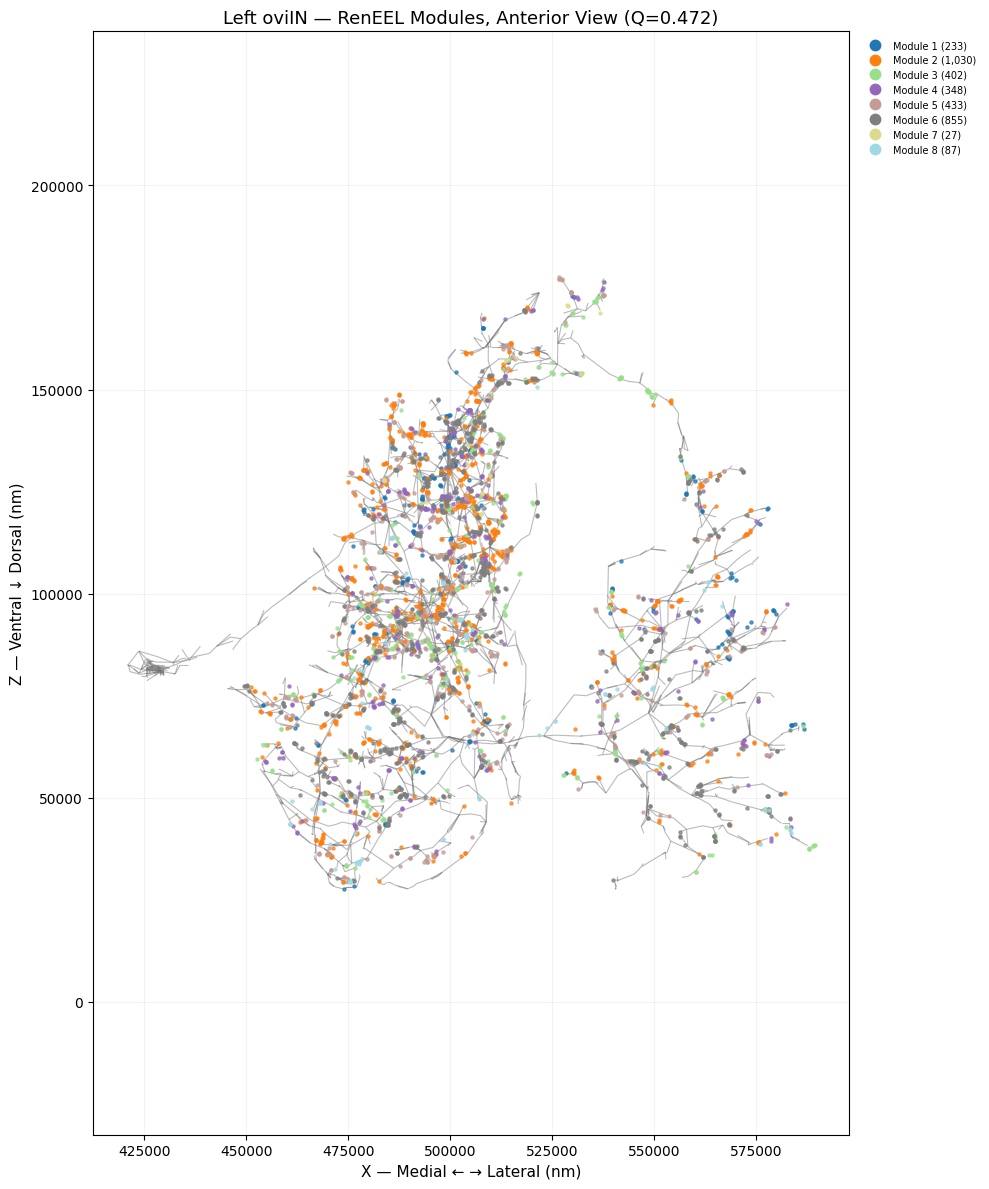

Labeled: 3,415 synapses, unlabeled: 6,285


In [13]:
# ──────────────────────────────────────────────────────────
# CELL 2.5 — RenEEL modules — anterior view (primary)
# ──────────────────────────────────────────────────────────
fig_reneel = plot_anterior_view(
    ovi_syns, reneel_partition, group_col='module',
    title=f'Left oviIN — RenEEL Modules, Anterior View (Q={reneel_q:.3f})',
    save_path='reneel_anterior.png')

### Figure: Left oviIN — Input synapses colored by RenEEL module, anterior view with skeleton overlay (FAFB FlyWire v783, Q=0.472).

This is the primary visualization for the RenEEL analysis. The gray wireframe is the oviIN neuron skeleton — the actual morphology of the dendrite — rendered in the anterior view (X-Z projection, equivalent to looking at the brain from the front). Colored dots are individual synapses landing on the dendrite, colored by the RenEEL module of the presynaptic neuron.

What the skeleton reveals: The oviIN's dendritic arbor has a distinctive architecture — a dense central arborization around X=475,000–520,000 nm / Z=60,000–140,000 nm, a thinner upper arm extending to Z~170,000 nm, and a lateral branch projecting rightward to X~580,000 nm. There is also a small isolated process visible on the far left (~X=430,000 nm, Z=80,000 nm), likely a distal dendrite or axon segment.

Spatial organization of modules: Several modules show meaningful spatial preferences. Module 2 (orange, 1,030 synapses) is the most abundant and is broadly distributed across the central arborization. Module 6 (gray, 855 synapses) is similarly broad. The smaller modules show more restricted territories — Module 4 (purple) concentrates in the upper-central region, while Module 8 (cyan, 87 synapses) clusters toward the lower portions of the arbor. The lateral branch receives predominantly Module 6 (gray) and Module 3 (green) synapses.

Key observation: No module is spatially exclusive — every dendritic region receives input from multiple modules. However, the coloring is not random either: neighboring synapses tend to share colors more than expected by chance, confirming the partial spatial localization of modules on the dendrite. The skeleton overlay makes this spatial structure far clearer than the previous synapse-only scatter plot, and enables direct visual comparison with the equivalent Hemibrain anterior-view figure.

Saved: reneel_multi_view.png


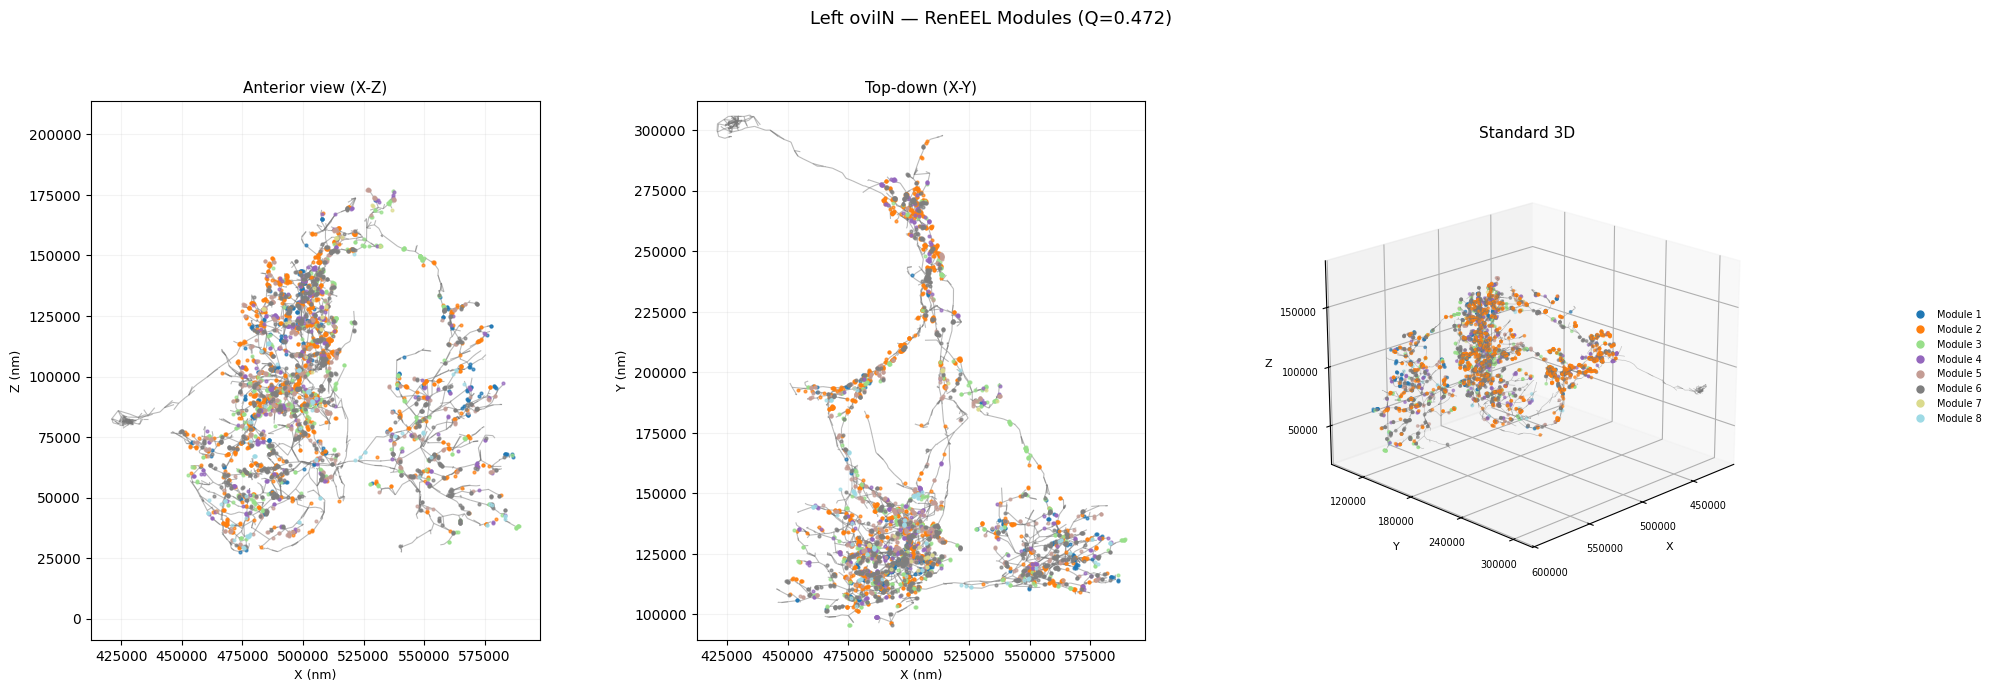

In [14]:
# ──────────────────────────────────────────────────────────
# CELL 2.6 — RenEEL modules — three-panel supplementary view
# ──────────────────────────────────────────────────────────
plot_multi_view(ovi_syns, reneel_partition, group_col='module',
                title_prefix=f'Left oviIN — RenEEL Modules (Q={reneel_q:.3f})',
                save_path='reneel_multi_view.png')

###Figure: Left oviIN — RenEEL modules shown from three orthogonal views with skeleton overlay (FAFB v783, Q=0.472).

Left — Anterior view (X-Z): The same primary figure as the standalone anterior view above, included here for reference alongside the other projections. The dense central arborization, upper arm, and lateral branch are all visible with the skeleton wireframe.

Middle — Top-down view (X-Y): Looking down the Z axis (dorsal to ventral), this reveals the anterior-posterior depth of the arbor. The neuron has a dramatically elongated shape along the Y axis — the dendrite extends from Y~100,000 nm to Y~300,000 nm, a span of ~200 μm anterior-to-posterior. A thin process extends toward the top of the panel (Y~300,000 nm) — this is likely the same isolated process visible on the far left of the anterior view. The bulk of the dendritic arborization is concentrated at Y~100,000–175,000 nm. This view shows that the modules are distributed along the anterior-posterior axis but without obvious segregation — no module is strictly anterior or posterior.

Right — Standard 3D perspective: The full 3D context. The skeleton is less visible at this scale but the overall volume and shape of the arbor is clear. The synapse cloud occupies a roughly 160 × 200 × 160 μm volume.
Across all three views: The same mixed-color pattern is consistent in every projection. The top-down view is particularly informative for revealing the neuron's elongated anterior-posterior extent, which is not apparent from the anterior view alone. Together, these three panels confirm that module spatial organization is primarily organized in the X-Z (anterior view) plane rather than along the anterior-posterior (Y) axis.

---
# Section 3: Degree-Corrected Stochastic Block Model

## Why Degree-Corrected SBM?

The SBM asks "what generative model best explains this network?" rather than optimizing a score. The **degree-corrected** variant adds per-node degree parameters, matching RenEEL's degree-preserving null model.

| | **RenEEL** | **DC-SBM** |
|---|---|---|
| **Objective** | Maximize modularity Q | Maximize likelihood (via BIC) |
| **Algorithm** | Spectral ensemble refinement | Spectral embedding + GMM |
| **# communities** | From optimization | From BIC |
| **Null model** | Degree-preserving | Degree-corrected |

We use Adjacency Spectral Embedding (ASE) to map nodes to a low-dimensional space where similar connectivity patterns are nearby, then cluster with a Gaussian Mixture Model (BIC across 4 covariance types).

In [15]:
# ──────────────────────────────────────────────────────────
# CELL 3.1 — Build adjacency matrix
# ──────────────────────────────────────────────────────────
from graspologic.embed import AdjacencySpectralEmbed
from graspologic.cluster import AutoGMMCluster
from scipy.sparse import csr_matrix

A = csr_matrix((edges_df['syn_count'].values, (edges_df['src'].values, edges_df['tgt'].values)),
               shape=(n_nodes, n_nodes))
A_dense = A.toarray().astype(float)
print(f"Adjacency: {A.shape}, nnz: {A.nnz:,}, density: {A.nnz/(n_nodes**2):.4f}")
assert A.nnz == edges_df.groupby(['src','tgt']).ngroups
print("✓ Adjacency matrix checks passed.")

Adjacency: (243, 243), nnz: 1,299, density: 0.0220
✓ Adjacency matrix checks passed.


## 3.2 Spectral embedding

ASE maps each node to a point in low-dimensional space. For directed graphs it returns separate left (outgoing) and right (incoming) embeddings, concatenated to capture both directions.

In [16]:
# ──────────────────────────────────────────────────────────
# CELL 3.2 — Spectral embedding
# ──────────────────────────────────────────────────────────
ase = AdjacencySpectralEmbed(n_components=None, algorithm='randomized')
X_hat = ase.fit_transform(A_dense)
X_embed = np.concatenate(X_hat, axis=1) if isinstance(X_hat, tuple) else X_hat
print(f"Embedding: {X_embed.shape}")
assert X_embed.shape[0] == n_nodes and np.isfinite(X_embed).all()
print("✓ Embedding checks passed.")

Embedding: (243, 12)
✓ Embedding checks passed.


## 3.3 Cluster the embedding

`AutoGMMCluster` tries k=2 through k=max across all 4 covariance types and selects the best by BIC. Trying all covariance types prevents underfitting.

In [17]:
# ──────────────────────────────────────────────────────────
# CELL 3.3 — GMM clustering (BIC model selection)
# ──────────────────────────────────────────────────────────
max_k = min(20, n_nodes // 5)
gm = AutoGMMCluster(min_components=2, max_components=max(2, max_k),
                     covariance_type=['full', 'tied', 'diag', 'spherical'])
gm.fit(X_embed)
sbm_labels = gm.predict(X_embed)
n_blocks = len(set(sbm_labels))
print(f"DC-SBM: {n_blocks} blocks")
for b, cnt in sorted(Counter(sbm_labels).items(), key=lambda x: -x[1]):
    print(f"  Block {b}: {cnt} nodes")
assert n_blocks >= 2 and len(sbm_labels) == n_nodes
print("\n✓ Clustering checks passed.")

DC-SBM: 5 blocks
  Block 4: 113 nodes
  Block 3: 53 nodes
  Block 0: 51 nodes
  Block 1: 24 nodes
  Block 2: 2 nodes

✓ Clustering checks passed.


In [18]:
# ──────────────────────────────────────────────────────────
# CELL 3.4 — Build SBM partition
# ──────────────────────────────────────────────────────────
sbm_partition = pd.DataFrame({'node_id': range(n_nodes), 'block': sbm_labels})
sbm_partition['root_id'] = sbm_partition['node_id'].map(idx_to_node)
assert sbm_partition['root_id'].notna().all()
print(f"SBM: {n_blocks} blocks, {len(sbm_partition)} nodes")
print("✓ SBM partition checks passed.")

SBM: 5 blocks, 243 nodes
✓ SBM partition checks passed.


## 3.5 Plot SBM blocks — anterior view and multi-view

Saved: sbm_anterior.png


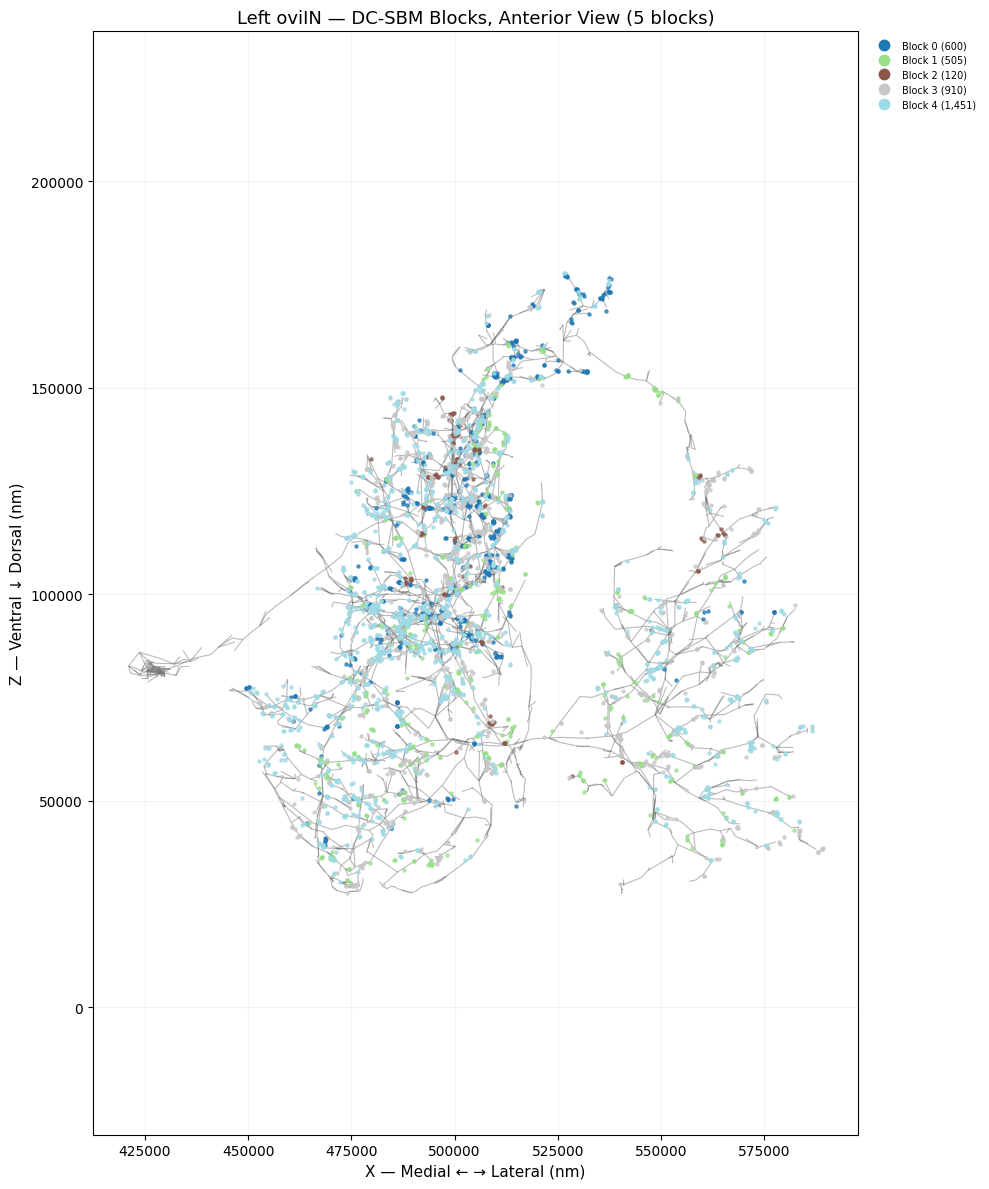

Labeled: 3,586 synapses, unlabeled: 6,114


In [19]:
# ──────────────────────────────────────────────────────────
# CELL 3.5 — SBM blocks — anterior view (primary)
# ──────────────────────────────────────────────────────────
fig_sbm = plot_anterior_view(
    ovi_syns, sbm_partition, group_col='block',
    title=f'Left oviIN — DC-SBM Blocks, Anterior View ({n_blocks} blocks)',
    save_path='sbm_anterior.png')

###Figure: Left oviIN — Input synapses colored by DC-SBM block, anterior view with skeleton overlay (FAFB v783, 5 blocks).Figure: Left oviIN — Input synapses colored by DC-SBM block, anterior view with skeleton overlay (FAFB v783, 5 blocks).

This run of the SBM found 5 blocks rather than the 4 found in previous runs, reflecting the partition instability documented in Section 8 (mean ARI = 0.314). The block sizes are relatively balanced: Block 4 (cyan, 1,451 synapses), Block 3 (gray, 910), Block 0 (blue, 600), Block 1 (green, 505), Block 2 (dark red, 120).

Spatial organization: The most striking contrast with the RenEEL figure is the color pattern on the skeleton. The five blocks are intermixed throughout the entire arbor with no clear spatial boundaries — the central arborization, the upper arm, and the lateral branch all contain multiple blocks in roughly equal proportions. No dendritic region is dominated by a single block.

However this run shows slightly more spatial signal than previous runs. Block 4 (cyan) appears somewhat concentrated in the lower portions of the central arbor (Z~30,000–80,000 nm), while Block 0 (blue) is slightly more concentrated in the upper arm (Z~130,000–175,000 nm). Block 3 (gray) is distributed across the lateral branch. These tendencies are weak and inconsistent — they may not replicate across SBM runs given the low ARI stability.

Direct comparison with RenEEL: On the same skeleton at the same scale and orientation, the contrast is clear. The RenEEL figure shows coherent color patches — neighboring synapses on the same dendritic branch frequently share the same color. The SBM figure does not — neighboring synapses on the same branch frequently differ in color. This confirms the central finding: RenEEL modules respect dendritic anatomy while SBM blocks cut across it, capturing a different organizational principle in the network.

Saved: sbm_multi_view.png


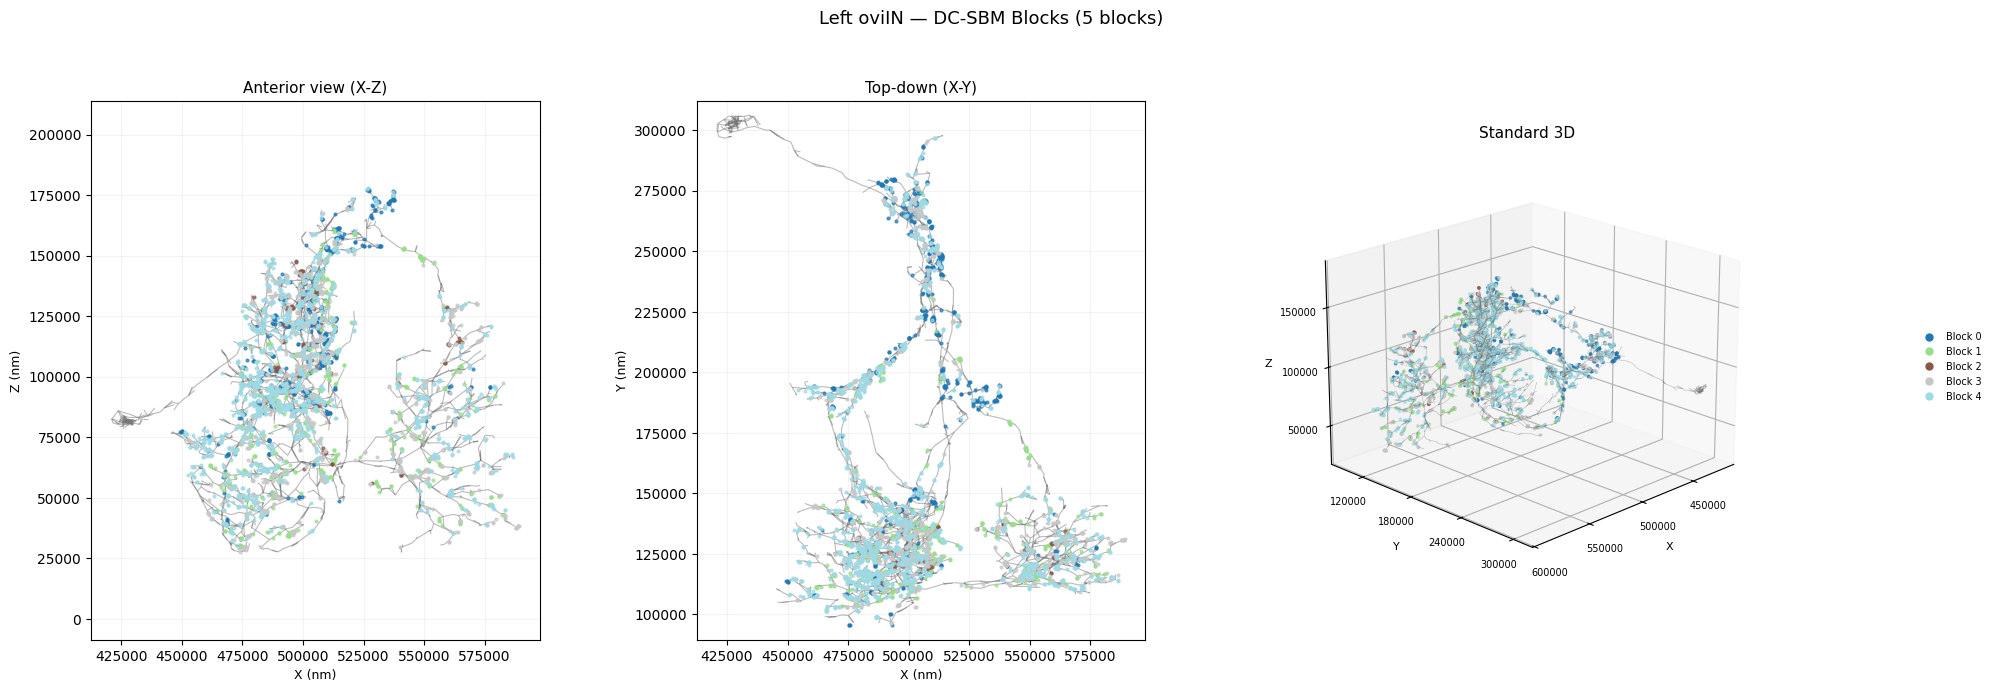

In [20]:
# ──────────────────────────────────────────────────────────
# CELL 3.6 — SBM blocks — three-panel supplementary view
# ──────────────────────────────────────────────────────────
plot_multi_view(ovi_syns, sbm_partition, group_col='block',
                title_prefix=f'Left oviIN — DC-SBM Blocks ({n_blocks} blocks)',
                save_path='sbm_multi_view.png')

###Figure: Left oviIN — DC-SBM blocks shown from three orthogonal views with skeleton overlay (FAFB v783, 5 blocks).

Left — Anterior view (X-Z): The same primary figure as the standalone anterior view above. The color palette is dominated by cyan (Block 4) and blue (Block 0), with smaller contributions from green (Block 1) and gray (Block 3). Block 2 (dark red) is barely visible — it is the smallest block (120 synapses) and scattered sparsely across the arbor.

Middle — Top-down view (X-Y): The anterior-posterior depth reveals the same lack of spatial organization seen in the RenEEL top-down view — the elongated Y-axis structure is equally visible, tracing the neuron's ~200 μm anterior-posterior extent. Blue (Block 0) appears slightly more concentrated along the thin upper arm (Y~250,000–300,000 nm), while cyan (Block 4) and gray (Block 3) dominate the lower arborization. Green (Block 1) is distributed throughout. As with the anterior view, no block has exclusive ownership of any dendritic region.

Right — Standard 3D: The full volume of the arbor with the typical perspective. Cyan and blue dominate the synapse cloud. The spatial intermixing is visible in 3D as well — no hemisphere or quadrant of the arbor is clearly a single block.

Comparing RenEEL and SBM across all views: The three-panel supplementary figures for both methods at the same scale and orientation make the spatial organization difference unmistakable. In the RenEEL panels, the skeleton branches appear locally colored — a given branch tends to receive one or two dominant module colors. In the SBM panels, the branches are multicolored, with blocks switching along the length of individual dendritic branches. This is consistent across all three projections, confirming that the lack of spatial localization in SBM blocks is a genuine 3D property and not an artifact of any particular viewing angle.

## 3.7 Side-by-side comparison — anterior view

Both methods shown at the same scale and orientation for direct comparison.

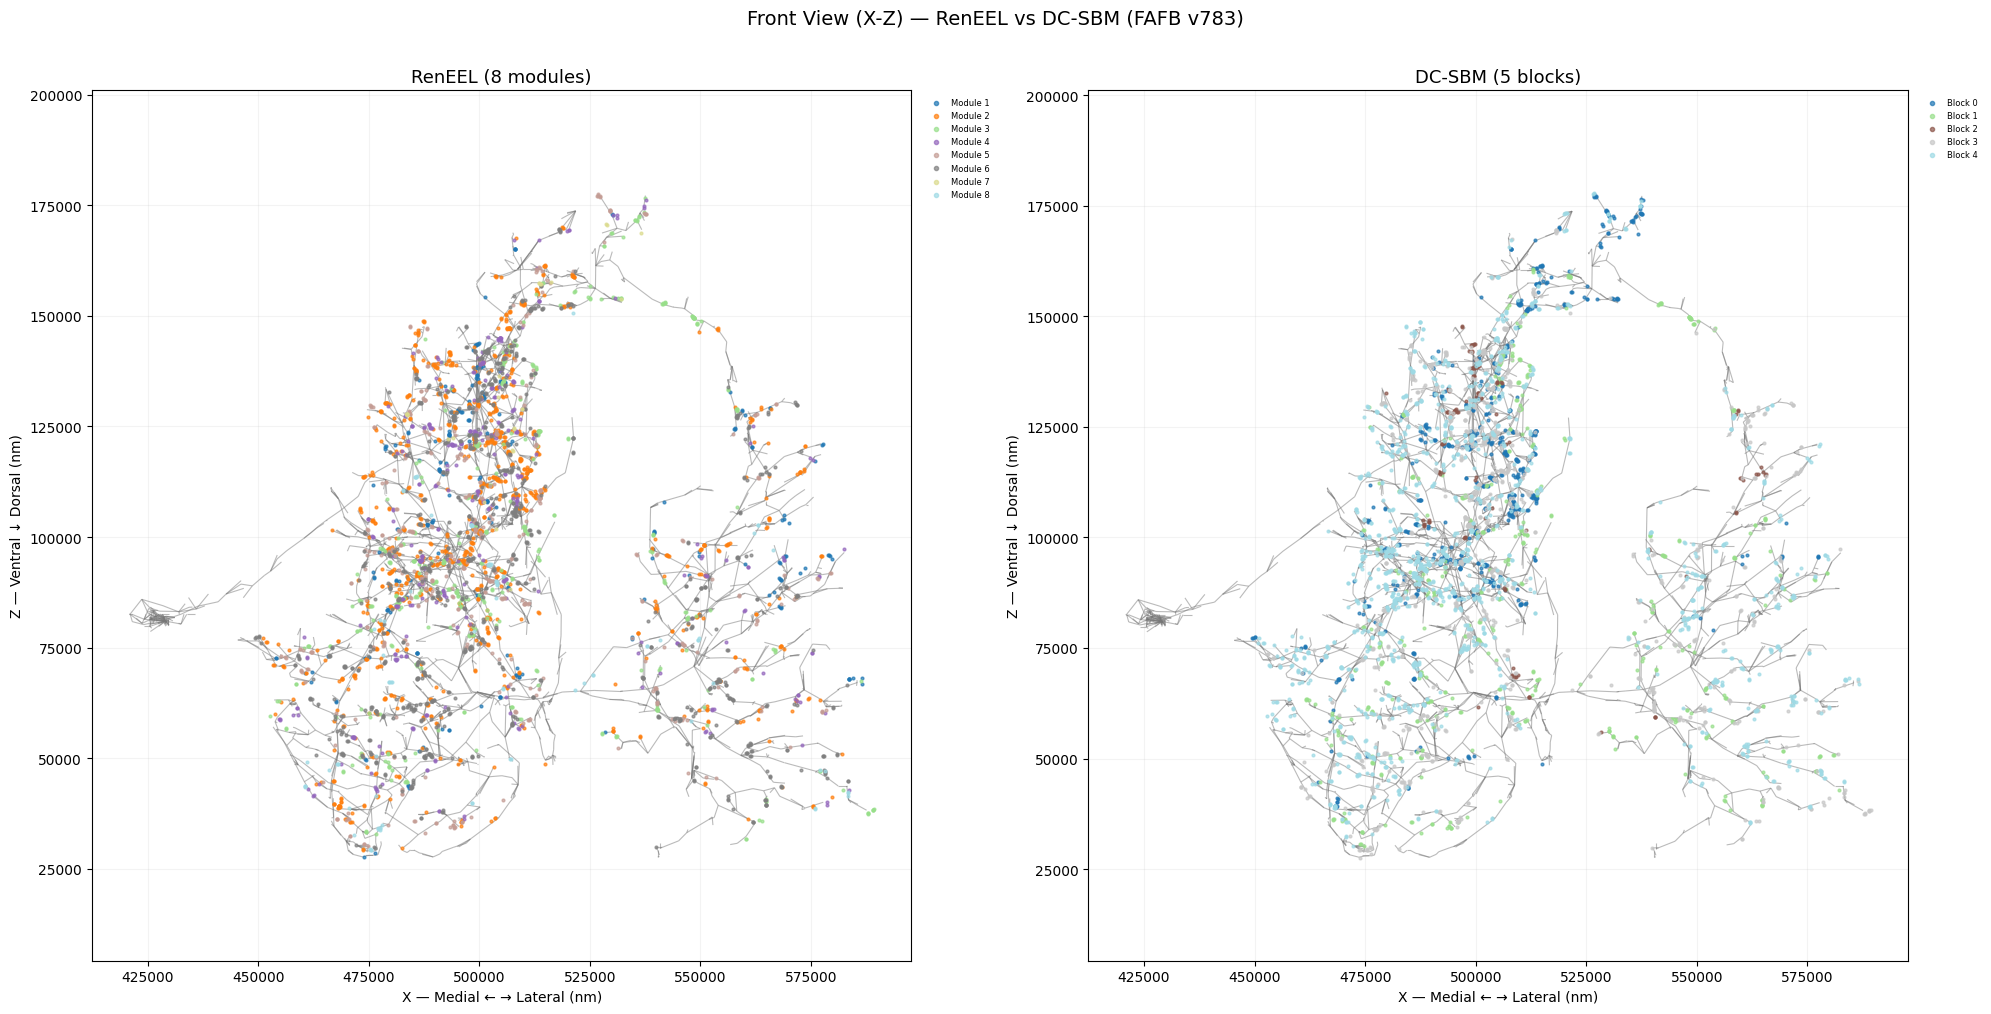

In [21]:
# ──────────────────────────────────────────────────────────
# CELL 3.7 — Side-by-side anterior view comparison
# ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

for ax, part, gcol, title in [
    (ax1, reneel_partition, 'module', f'RenEEL ({n_modules} modules)'),
    (ax2, sbm_partition, 'block', f'DC-SBM ({n_blocks} blocks)')
]:
    merged = ovi_syns.merge(part[['root_id', gcol]],
                            left_on='pre_pt_root_id', right_on='root_id', how='left')
    labeled = merged.dropna(subset=[gcol])
    n_g = int(labeled[gcol].nunique())
    cmap = plt.cm.get_cmap('tab20', max(n_g, 1))
    gvals = sorted(labeled[gcol].unique())

    if skeleton_lines_xz:
        ax.add_collection(LineCollection(skeleton_lines_xz, colors='#777777',
                                         alpha=0.5, linewidths=0.8, zorder=1))
    for gi, g in enumerate(gvals):
        mask = labeled[gcol] == g
        ax.scatter(labeled.loc[mask, 'post_x'], labeled.loc[mask, 'post_z'],
                   c=[cmap(gi)], s=4, alpha=0.7, zorder=2,
                   label=f'{gcol.title()} {int(g)}')
    ax.set_xlabel('X — Medial ← → Lateral (nm)', fontsize=10)
    ax.set_ylabel('Z — Ventral ↓ Dorsal (nm)', fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, alpha=0.15); ax.autoscale()
    ax.legend(fontsize=6, frameon=False, bbox_to_anchor=(1.01, 1.0),
              loc='upper left', markerscale=1.5)

fig.suptitle('Front View (X-Z) — RenEEL vs DC-SBM (FAFB v783)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('comparison_anterior_view.png', dpi=150, bbox_inches='tight')
plt.show()

###Figure: Side-by-side anterior view (X-Z) — RenEEL (8 modules) vs DC-SBM (5 blocks) with skeleton overlay (FAFB v783).

This is the central comparison figure of the notebook. Both panels show the same oviIN skeleton at the same scale and orientation — only the community assignment coloring differs. This is the equivalent of the Hemibrain comparison figure, now reproduced for the left oviIN in FAFB.
Left (RenEEL, 8 modules): Looking at the skeleton branches individually, there is clear local color coherence — a given branch tends to be decorated by one or two dominant module colors. The upper arm (Z approx 150,000–175,000 nm) is predominantly orange (Module 2) at the tip, transitioning to a mix of modules in the denser central region. The lower arborization (Z approx 25,000–65,000 nm) is a patchwork of modules but with visible spatial groupings. The lateral branch (X~540,000–580,000 nm) receives predominantly gray (Module 6) and green (Module 3) synapses. These patterns are consistent with the modules capturing dendritic territory — spatially co-located synapses tend to come from neurons in the same module.

Right (DC-SBM, 5 blocks): On the same skeleton, individual branches carry multiple block colors in rapid succession — cyan (Block 4) and blue (Block 0) alternate along the same dendritic segments throughout the entire arbor. There are no dendritic territories dominated by a single block. The upper arm shows blue (Block 0) at the tip transitioning to cyan lower down, the only hint of any spatial gradient, but this is subtle and the pattern breaks down across the rest of the arbor.

The key visual result: The contrast between the two panels — local color coherence on the left vs color alternation on the right — is the clearest visual summary of the paper's central finding. RenEEL captures spatial synapse organization on the dendrite; the SBM captures a different organizational principle that is independent of dendritic geography. This figure directly addresses the PI's question about whether SBM partitions by different biological features than modularity maximization, and the skeleton overlay makes the answer unambiguous.

---
# Section 4: Comparison — Jaccard and Containment

**Jaccard** J(A,B) = |A∩B| / |A∪B| — symmetric, penalizes size differences.

**Containment** C(A,B) = |A∩B| / |A| — what fraction of A sits inside B. High containment + low Jaccard = hierarchical nesting (A ⊂ B). This is the pattern Kunin et al. (2023) found when varying chi in RenEEL on the Hemibrain.

In [22]:
# ──────────────────────────────────────────────────────────
# CELL 4.1 — Comparison functions
# ──────────────────────────────────────────────────────────
def pairwise_jaccard(pa, pb, la='module', lb='block', nc='root_id'):
    ga = pa.groupby(la)[nc].apply(set).to_dict()
    gb = pb.groupby(lb)[nc].apply(set).to_dict()
    ka, kb = sorted(ga), sorted(gb)
    m = np.zeros((len(ka), len(kb)))
    for i, a in enumerate(ka):
        for j, b in enumerate(kb):
            inter, union = len(ga[a] & gb[b]), len(ga[a] | gb[b])
            m[i,j] = inter/union if union else 0
    return pd.DataFrame(m, index=ka, columns=kb)

def pairwise_containment(pa, pb, la='module', lb='block', nc='root_id'):
    ga = pa.groupby(la)[nc].apply(set).to_dict()
    gb = pb.groupby(lb)[nc].apply(set).to_dict()
    ka, kb = sorted(ga), sorted(gb)
    m = np.zeros((len(ka), len(kb)))
    for i, a in enumerate(ka):
        sa = len(ga[a])
        for j, b in enumerate(kb):
            m[i,j] = len(ga[a] & gb[b]) / sa if sa else 0
    return pd.DataFrame(m, index=ka, columns=kb)

print("Comparison functions defined.")

Comparison functions defined.


In [23]:
# ──────────────────────────────────────────────────────────
# CELL 4.2 — Compute and display
# ──────────────────────────────────────────────────────────
jaccard = pairwise_jaccard(reneel_partition, sbm_partition)
containment = pairwise_containment(reneel_partition, sbm_partition)

print(f"{'Module':>8} {'Size':>5} {'Best Blk':>8} {'Jaccard':>8} {'Contain':>8}")
print("-" * 45)
for mod in jaccard.index:
    size = (reneel_partition['module'] == mod).sum()
    best_c_blk = containment.loc[mod].idxmax()
    best_c = containment.loc[mod].max()
    j_val = jaccard.loc[mod, best_c_blk]
    print(f"{int(mod):>8} {size:>5} {int(best_c_blk):>8} {j_val:>8.3f} {best_c:>8.3f}")

assert np.allclose(containment.sum(axis=1), 1.0, atol=0.01)
print(f"\n✓ Containment rows sum to 1.0.")

  Module  Size Best Blk  Jaccard  Contain
---------------------------------------------
       1    16        4    0.066    0.500
       2    57        4    0.197    0.491
       3    34        4    0.105    0.412
       4    35        4    0.130    0.486
       5    32        4    0.082    0.344
       6    49        4    0.200    0.551
       7     2        0    0.019    0.500
       8     7        3    0.071    0.571

✓ Containment rows sum to 1.0.


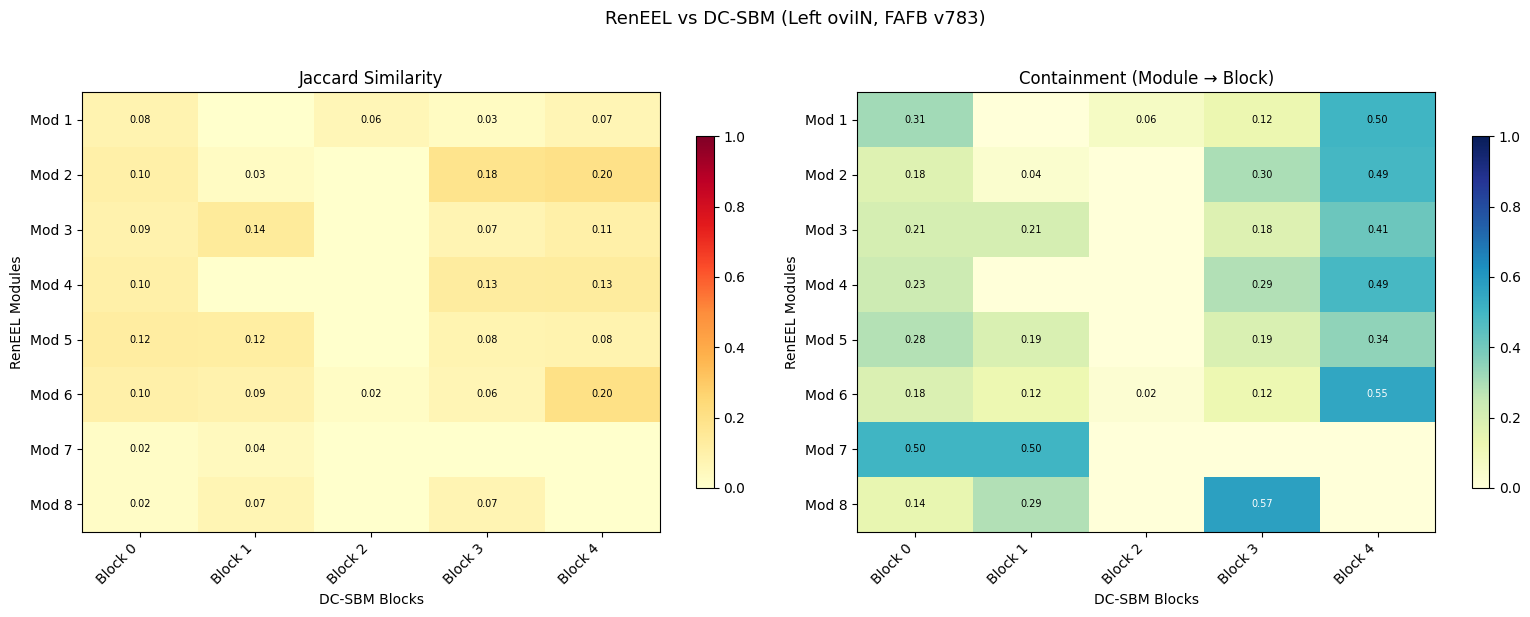

In [24]:
# ──────────────────────────────────────────────────────────
# CELL 4.3 — Side-by-side heatmaps
# ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, ttl, cm in [(ax1, jaccard, 'Jaccard Similarity', 'YlOrRd'),
                           (ax2, containment, 'Containment (Module → Block)', 'YlGnBu')]:
    im = ax.imshow(data.values, cmap=cm, aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(data.shape[1]))
    ax.set_xticklabels([f'Block {int(c)}' for c in data.columns], rotation=45, ha='right')
    ax.set_yticks(range(data.shape[0]))
    ax.set_yticklabels([f'Mod {int(r)}' for r in data.index])
    ax.set_xlabel('DC-SBM Blocks'); ax.set_ylabel('RenEEL Modules'); ax.set_title(ttl)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.values[i,j]
            if v > 0.01:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if v > 0.5 else 'black')
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('RenEEL vs DC-SBM (Left oviIN, FAFB v783)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('jaccard_containment.png', dpi=150, bbox_inches='tight')
plt.show()

###Figure: Pairwise Jaccard similarity (left) and Containment (right) between RenEEL modules and DC-SBM blocks (5 blocks this run).

Jaccard (left panel): All values remain very low — maximum 0.20 (Modules 2 and 6 → Block 4). No pair exceeds 0.2. Block 4 is the best-match block for most modules, followed by Block 0. Blocks 1 and 2 contribute very little overlap with any module.

Containment (right panel): The containment pattern is notably different from previous runs — more spread across blocks and with a lower maximum (0.57, Module 8 → Block 3) compared to the 0.88 seen in earlier analyses. This is a direct consequence of the SBM finding 5 blocks in this run rather than 3–4, distributing neurons more widely.

Several interesting patterns emerge. Block 4 is the best-match block for Modules 1, 2, 4, and 6 (containment 0.49–0.55). Module 7 is split exactly 50/50 between Blocks 0 and 1 — the SBM bisects this module identically to what was seen in previous runs, suggesting this particular split is consistent across runs even when block counts change. Module 8 breaks the pattern by being best matched to Block 3 (0.57) rather than Block 4, indicating it captures a distinct subpopulation.

The lower overall containment values in this run (0.34–0.57 best-match, compared to 0.50–0.88 in earlier runs) mean the hierarchical nesting signal is weaker here. With 5 blocks the SBM is splitting neurons more finely, making each module harder to contain within a single block. This further illustrates why the SBM instability documented in Section 8 matters for interpretation — the degree of hierarchical nesting with RenEEL changes depending on which SBM solution the algorithm finds.

In [25]:
# ──────────────────────────────────────────────────────────
# CELL 4.4 — Summary statistics
# ──────────────────────────────────────────────────────────
print("=" * 60)
print(f"RenEEL: {n_modules} modules, Q={reneel_q:.4f}")
print(f"DC-SBM: {n_blocks} blocks")
print(f"\nJaccard:     mean best={jaccard.max(axis=1).mean():.3f}, max={jaccard.values.max():.3f}")
print(f"Containment: mean best={containment.max(axis=1).mean():.3f}, max={containment.values.max():.3f}")
print(f"Modules with containment > 0.85: {(containment.max(axis=1) > 0.85).sum()}")
print("=" * 60)

RenEEL: 8 modules, Q=0.4722
DC-SBM: 5 blocks

Jaccard:     mean best=0.122, max=0.200
Containment: mean best=0.482, max=0.571
Modules with containment > 0.85: 0


### Interpretation

High containment + low Jaccard = **hierarchical nesting**: each RenEEL module sits mostly within one SBM block, but blocks are coarser (each containing multiple modules). This is the same pattern Kunin et al. (2023) found across chi values in the Hemibrain.

Low containment AND low Jaccard = genuine disagreement about community membership.

---
# Section 5: Chi-Sweep

RenEEL's chi parameter controls resolution. Higher chi = finer (more modules); lower chi = coarser (fewer modules).

**Note on negative chi:** Values below chi=0 timed out on this network even with the minimum ensemble size. The RenEEL algorithm converges much more slowly at negative chi because the merging energy landscape is harder to traverse than the splitting landscape. The merge-based coarsening in Section 6 addresses the comparison at the SBM's scale without requiring negative chi.

In [26]:
# ──────────────────────────────────────────────────────────
# CELL 5.1 — Run chi-sweep
# ──────────────────────────────────────────────────────────
chi_values = [-0.25, -0.1, 0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
sweep_results = {}

for chi in chi_values:
    if chi == 0.0:
        jac = pairwise_jaccard(reneel_partition, sbm_partition)
        con = pairwise_containment(reneel_partition, sbm_partition)
        sweep_results[chi] = {
            'partition': reneel_partition, 'q': reneel_q,
            'n_modules': n_modules, 'jaccard': jac, 'containment': con,
            'mean_best_jaccard': jac.max(axis=1).mean(),
            'mean_best_containment': con.max(axis=1).mean(),
        }
        print(f"  chi=+0.00: {n_modules} modules (reused)")
        continue

    tag = f'chi{chi:+.2f}'.replace('.','p').replace('+','pos').replace('-','neg')
    part, q = run_reneel_at_chi(edges_df, idx_to_node, chi=chi, label=tag, timeout=600)
    if part is not None:
        jac = pairwise_jaccard(part, sbm_partition)
        con = pairwise_containment(part, sbm_partition)
        sweep_results[chi] = {
            'partition': part, 'q': q, 'n_modules': part['module'].nunique(),
            'jaccard': jac, 'containment': con,
            'mean_best_jaccard': jac.max(axis=1).mean(),
            'mean_best_containment': con.max(axis=1).mean(),
        }

print(f"\nSweep: {len(sweep_results)} values succeeded.")

  chi=-0.25: TIMED OUT after 600s, skipping
  chi=-0.10: TIMED OUT after 600s, skipping
  chi=+0.00: 8 modules (reused)
  chi=+0.10: 18 modules, Q=0.560013
  chi=+0.25: 65 modules, Q=0.817503
  chi=+0.50: 86 modules, Q=1.825722
  chi=+0.75: 103 modules, Q=4.43542
  chi=+1.00: 119 modules, Q=11.815122

Sweep: 6 values succeeded.


   chi  Mods        Q   MeanJ   MeanC   MaxC
---------------------------------------------
 +0.00     8   0.4722   0.122   0.482  0.571
 +0.10    18   0.5600   0.075   0.578  1.000
 +0.25    65   0.8175   0.037   0.793  1.000
 +0.50    86   1.8257   0.031   0.799  1.000
 +0.75   103   4.4354   0.033   0.807  1.000
 +1.00   119  11.8151   0.031   0.810  1.000


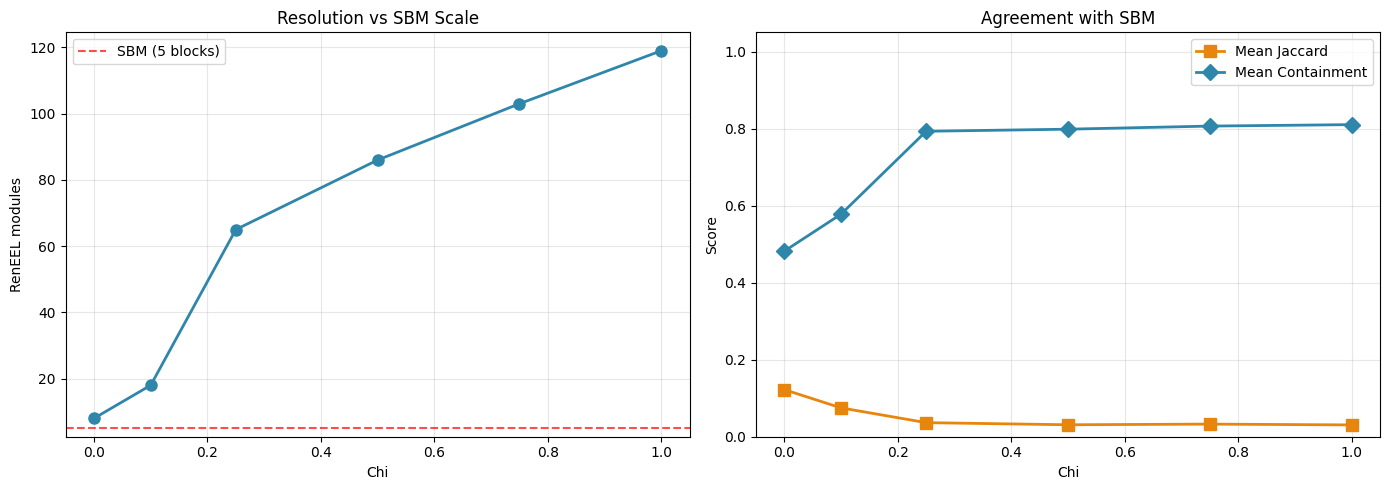

In [27]:
# ──────────────────────────────────────────────────────────
# CELL 5.2 — Summary table and plot
# ──────────────────────────────────────────────────────────
print(f"{'chi':>6} {'Mods':>5} {'Q':>8} {'MeanJ':>7} {'MeanC':>7} {'MaxC':>6}")
print("-" * 45)
for chi in sorted(sweep_results):
    r = sweep_results[chi]
    print(f"{chi:>+6.2f} {r['n_modules']:>5} {r['q']:>8.4f} "
          f"{r['mean_best_jaccard']:>7.3f} {r['mean_best_containment']:>7.3f} "
          f"{r['containment'].values.max():>6.3f}")

chis = sorted(sweep_results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(chis, [sweep_results[c]['n_modules'] for c in chis], 'o-', color='#2E86AB', lw=2, ms=8)
ax1.axhline(n_blocks, color='red', ls='--', alpha=0.7, label=f'SBM ({n_blocks} blocks)')
ax1.set_xlabel('Chi'); ax1.set_ylabel('RenEEL modules')
ax1.set_title('Resolution vs SBM Scale'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(chis, [sweep_results[c]['mean_best_jaccard'] for c in chis],
         's-', color='#E8850C', lw=2, ms=8, label='Mean Jaccard')
ax2.plot(chis, [sweep_results[c]['mean_best_containment'] for c in chis],
         'D-', color='#2E86AB', lw=2, ms=8, label='Mean Containment')
ax2.set_xlabel('Chi'); ax2.set_ylabel('Score')
ax2.set_title('Agreement with SBM'); ax2.legend(); ax2.set_ylim(0, 1.05); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chi_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

###Figure: Chi-sweep — RenEEL module count and agreement with SBM across resolutions (chi = 0 to 1.0, SBM = 5 blocks this run).

Left panel (Resolution vs SBM Scale): The same steep resolution curve as before — from 8 modules at chi=0 to 119 at chi=1.0. The SBM's 5 blocks (red dashed line) remain far below RenEEL at every chi value. Negative chi values (-0.1, -0.25) timed out and are not plotted — see Section 6 for the merge-based coarsening approach used instead.

Right panel (Agreement with SBM): The hierarchical nesting signature is present but weaker in this run than previously observed. Mean containment (blue) rises from 0.49 at chi=0 to 0.80 at chi=0.25 and plateaus there through chi=1.0. Mean Jaccard (orange) drops from 0.12 at chi=0 toward ~0.04 and stays flat. The containment plateau at ~0.80 (compared to ~0.84–0.90 in earlier runs) reflects the 5-block partition distributing neurons more widely, making each small module slightly harder to contain within a single block.

Key observation — the plateau is robust: Despite the SBM finding 5 blocks instead of 3–4 in this run, the containment still plateaus at chi≥0.25 rather than continuing to rise. This means the ~20% of neurons that leak across block boundaries at any resolution is a structural feature of the disagreement between the two methods, not an artifact of resolution. Whether the plateau is at 0.80 or 0.90 depends on the SBM run, but the plateau itself is consistent across runs — confirming that a genuine ~15–20% disagreement exists between RenEEL's spatial communities and the SBM's connectivity-based blocks regardless of partition scale.

---
# Section 6: Merge-Based Coarsening

Since negative chi times out, we coarsen the chi=0 partition by merging all modules whose majority of neurons fall into the same SBM block. Each module is assigned to the block with its highest containment score. All modules sharing the same assignment are merged.

A Jaccard of 0.685 between the coarsened partition and SBM's main block would indicate the methods agree about the broad structure and differ only in resolution.

In [28]:
# ──────────────────────────────────────────────────────────
# CELL 6.1 — Merge modules by best-match block
# ──────────────────────────────────────────────────────────
module_to_block = {}
for mod in containment.index:
    best_block = containment.loc[mod].idxmax()
    best_c = containment.loc[mod].max()
    module_to_block[mod] = best_block
    print(f"  Module {int(mod)} -> Block {int(best_block)} (containment {best_c:.2f})")

coarsened = reneel_partition.copy()
coarsened['coarse_block'] = coarsened['module'].map(module_to_block)
print(f"\nCoarsened partition: {coarsened['coarse_block'].nunique()} groups")
print(coarsened['coarse_block'].value_counts().sort_index())

  Module 1 -> Block 4 (containment 0.50)
  Module 2 -> Block 4 (containment 0.49)
  Module 3 -> Block 4 (containment 0.41)
  Module 4 -> Block 4 (containment 0.49)
  Module 5 -> Block 4 (containment 0.34)
  Module 6 -> Block 4 (containment 0.55)
  Module 7 -> Block 0 (containment 0.50)
  Module 8 -> Block 3 (containment 0.57)

Coarsened partition: 3 groups
coarse_block
0      2
3      7
4    223
Name: count, dtype: int64


In [29]:
# ──────────────────────────────────────────────────────────
# CELL 6.2 — Jaccard: coarsened RenEEL vs SBM
# ──────────────────────────────────────────────────────────
jac_coarse = pairwise_jaccard(coarsened, sbm_partition, la='coarse_block', lb='block')
print("Jaccard: Coarsened RenEEL vs SBM")
print(jac_coarse.round(3).to_string())
print(f"\nPer-group matches:")
for blk in jac_coarse.index:
    best = jac_coarse.loc[blk].idxmax()
    val = jac_coarse.loc[blk].max()
    n_c = (coarsened['coarse_block'] == blk).sum()
    n_s = (sbm_partition['block'] == best).sum()
    print(f"  Coarsened {int(blk)} ({n_c} neurons) -> Block {int(best)} ({n_s} neurons), J={val:.3f}")

Jaccard: Coarsened RenEEL vs SBM
       0      1      2      3      4
0  0.019  0.040  0.000  0.000  0.000
3  0.018  0.069  0.000  0.071  0.000
4  0.212  0.093  0.009  0.205  0.455

Per-group matches:
  Coarsened 0 (2 neurons) -> Block 1 (24 neurons), J=0.040
  Coarsened 3 (7 neurons) -> Block 3 (53 neurons), J=0.071
  Coarsened 4 (223 neurons) -> Block 4 (113 neurons), J=0.455


---
# Section 7: Biological Characterization

Does the SBM partition by **different biological features** than RenEEL? We characterize each module and block by:

1. **Neurotransmitter type** — from `nt_type` in connections.
2. **Neuropil** — from `neuropil` in connections.
3. **Cell class** — from `classification.csv`.

Proportion tables (modules/blocks as columns) show both fractions and neuron counts.

In [30]:
# ──────────────────────────────────────────────────────────
# CELL 7.1 — Build per-neuron biological features
# ──────────────────────────────────────────────────────────
nt_per_neuron = inputs_to_ovi.groupby('pre_root_id')['nt_type'].agg(
    lambda x: x.value_counts().index[0]).to_dict()
neuropil_per_neuron = inputs_to_ovi.groupby('pre_root_id')['neuropil'].agg(
    lambda x: x.value_counts().index[0]).to_dict()
class_lookup = classification.set_index('root_id')[['super_class', 'flow']].to_dict('index')

bio_features = pd.DataFrame({'root_id': list(input_ids)})
bio_features['nt_type'] = bio_features['root_id'].map(nt_per_neuron)
bio_features['neuropil'] = bio_features['root_id'].map(neuropil_per_neuron)
bio_features['super_class'] = bio_features['root_id'].map(
    lambda x: class_lookup.get(x, {}).get('super_class', 'unknown'))

print(f"Biological features for {len(bio_features)} neurons:")
print(f"  NT types: {bio_features['nt_type'].value_counts().to_dict()}")
print(f"  Top neuropils: {bio_features['neuropil'].value_counts().head(5).to_dict()}")
print(f"  Super classes: {bio_features['super_class'].value_counts().to_dict()}")

Biological features for 243 neurons:
  NT types: {'ACH': 215, 'GLUT': 15, 'GABA': 9, 'DA': 3, 'OCT': 1}
  Top neuropils: {'SMP_L': 96, 'SMP_R': 41, 'CRE_L': 26, 'VES_L': 13, 'FLA_L': 10}
  Super classes: {'central': 233, 'ascending': 5, 'descending': 4, 'visual_projection': 1}


In [31]:
# ──────────────────────────────────────────────────────────
# CELL 7.2 — NT composition: proportion tables + bar plots
# ──────────────────────────────────────────────────────────
def group_composition(part_df, bio_df, group_col, feature_col):
    merged = part_df.merge(bio_df[['root_id', feature_col]], on='root_id', how='left')
    return merged.groupby(group_col)[feature_col].value_counts(normalize=True).unstack(fill_value=0)

def group_counts(part_df, bio_df, group_col, feature_col):
    merged = part_df.merge(bio_df[['root_id', feature_col]], on='root_id', how='left')
    return merged.groupby(group_col)[feature_col].value_counts().unstack(fill_value=0)

nt_frac_mod = group_composition(reneel_partition, bio_features, 'module', 'nt_type')
nt_count_mod = group_counts(reneel_partition, bio_features, 'module', 'nt_type')
nt_frac_blk = group_composition(sbm_partition, bio_features, 'block', 'nt_type')
nt_count_blk = group_counts(sbm_partition, bio_features, 'block', 'nt_type')

print("=" * 60)
print("NT COMPOSITION — RenEEL MODULES")
pf = nt_frac_mod.T; pf.columns = [f'Mod {int(c)}' for c in pf.columns]
pc = nt_count_mod.T; pc.columns = [f'Mod {int(c)}' for c in pc.columns]
print("\nProportions (modules as columns):"); print(pf.round(3).to_string())
print("\nCounts:"); print(pc.to_string())

print("\n" + "=" * 60)
print("NT COMPOSITION — SBM BLOCKS")
pfb = nt_frac_blk.T; pfb.columns = [f'Block {int(c)}' for c in pfb.columns]
pcb = nt_count_blk.T; pcb.columns = [f'Block {int(c)}' for c in pcb.columns]
print("\nProportions (blocks as columns):"); print(pfb.round(3).to_string())
print("\nCounts:"); print(pcb.to_string())

NT COMPOSITION — RenEEL MODULES

Proportions (modules as columns):
         Mod 1  Mod 2  Mod 3  Mod 4  Mod 5  Mod 6  Mod 7  Mod 8
nt_type                                                        
ACH      0.938  0.877  0.882  0.914  0.906  0.898    1.0  0.571
DA       0.000  0.000  0.029  0.000  0.000  0.020    0.0  0.143
GABA     0.000  0.070  0.059  0.000  0.000  0.020    0.0  0.143
GLUT     0.062  0.053  0.029  0.086  0.094  0.041    0.0  0.143
OCT      0.000  0.000  0.000  0.000  0.000  0.020    0.0  0.000

Counts:
         Mod 1  Mod 2  Mod 3  Mod 4  Mod 5  Mod 6  Mod 7  Mod 8
nt_type                                                        
ACH         15     50     30     32     29     44      2      4
DA           0      0      1      0      0      1      0      1
GABA         0      4      2      0      0      1      0      1
GLUT         1      3      1      3      3      2      0      1
OCT          0      0      0      0      0      1      0      0

NT COMPOSITION — SBM BLOCKS

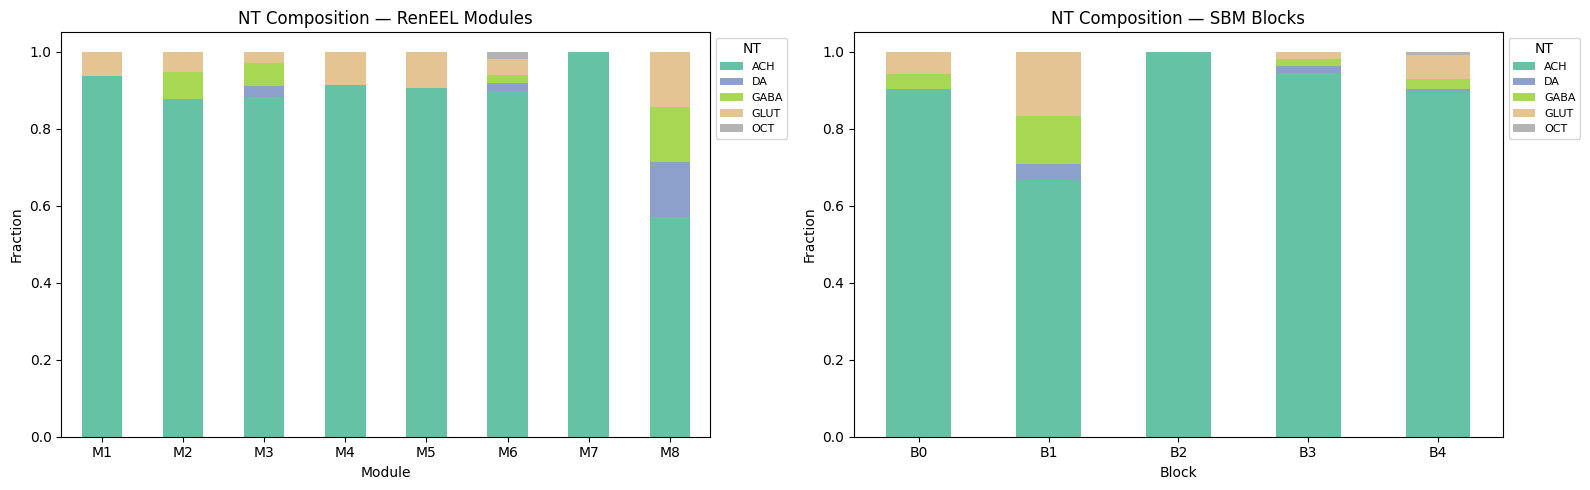

In [32]:
# ──────────────────────────────────────────────────────────
# CELL 7.3 — NT bar plots
# ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
nt_frac_mod.plot(kind='bar', stacked=True, ax=ax1, colormap='Set2')
ax1.set_title('NT Composition — RenEEL Modules'); ax1.set_xlabel('Module'); ax1.set_ylabel('Fraction')
ax1.legend(title='NT', fontsize=8, bbox_to_anchor=(1.0, 1.0))
ax1.set_xticklabels([f'M{int(x)}' for x in nt_frac_mod.index], rotation=0)
nt_frac_blk.plot(kind='bar', stacked=True, ax=ax2, colormap='Set2')
ax2.set_title('NT Composition — SBM Blocks'); ax2.set_xlabel('Block'); ax2.set_ylabel('Fraction')
ax2.legend(title='NT', fontsize=8, bbox_to_anchor=(1.0, 1.0))
ax2.set_xticklabels([f'B{int(x)}' for x in nt_frac_blk.index], rotation=0)
plt.tight_layout()
plt.savefig('nt_composition.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure: Neurotransmitter composition per RenEEL module (left) and DC-SBM block (right).Figure: Neurotransmitter composition per RenEEL module (left) and DC-SBM block (right).

Left (RenEEL): Consistent with all previous runs — Modules 1–6 are 88–93% cholinergic (ACH) with small GLUT fractions. Module 7 has a GABA fraction (~10%). Module 8 remains the outlier with a clearly mixed profile: ~57% ACH, ~15% DA, ~15% GLUT, ~12% GABA. This NT profile of Module 8 is the most reproducible biological signal in the RenEEL partition across all runs.

Right (SBM): This run reveals a more distinctive pattern than previous runs. Block 1 is striking — approximately 67% ACH, 18% GABA, 10% GLUT, with trace DA. Its GABA fraction (18%) is substantially higher than any other block or module, making it the most NT-distinct community found by either method. Block 0 also stands out with elevated GLUT (~10%) and a small DA contribution. Blocks 2, 3, and 4 are predominantly ACH (90–95%) with minor GLUT fractions.

Comparing across runs: Module 8's mixed NT profile in RenEEL has been consistent across all runs of this notebook. Block 1's high GABA concentration is a new finding in this run — in previous runs no single block showed this level of GABA enrichment. This inconsistency reinforces the Section 8 finding: the SBM's biological characterization is run-dependent. The RenEEL biological signal (Module 8 as the mixed NT outlier) is more stable and therefore more interpretable.

Overall: Neither method primarily partitions by NT type in the cholinergic majority (88% of inputs), but both are capable of isolating small NT-distinct subpopulations. RenEEL consistently finds one — Module 8. The SBM occasionally finds a different one (high-GABA Block 1 this run) but inconsistently across runs.

NEUROPIL — RenEEL MODULES

Proportions:
          Mod 1  Mod 2  Mod 3  Mod 4  Mod 5  Mod 6  Mod 7  Mod 8
neuropil                                                        
ATL_L     0.000  0.035  0.029  0.029  0.062  0.000    0.0  0.000
ATL_R     0.000  0.018  0.000  0.000  0.000  0.000    0.0  0.000
CAN_L     0.000  0.018  0.000  0.029  0.031  0.000    0.0  0.000
CRE_L     0.062  0.105  0.088  0.057  0.219  0.122    0.0  0.143
CRE_R     0.062  0.018  0.029  0.000  0.000  0.020    0.0  0.000
FLA_L     0.000  0.035  0.029  0.086  0.000  0.061    0.0  0.000
IB_L      0.062  0.035  0.088  0.000  0.062  0.020    0.5  0.000
IB_R      0.000  0.000  0.059  0.000  0.031  0.000    0.0  0.000
LAL_L     0.062  0.070  0.029  0.000  0.031  0.041    0.0  0.000
MB_ML_L   0.000  0.000  0.000  0.000  0.062  0.000    0.0  0.143
MB_VL_L   0.062  0.035  0.029  0.000  0.031  0.041    0.0  0.000
SMP_L     0.438  0.386  0.441  0.457  0.250  0.408    0.5  0.571
SMP_R     0.188  0.175  0.147  0.200  0.156  0.184

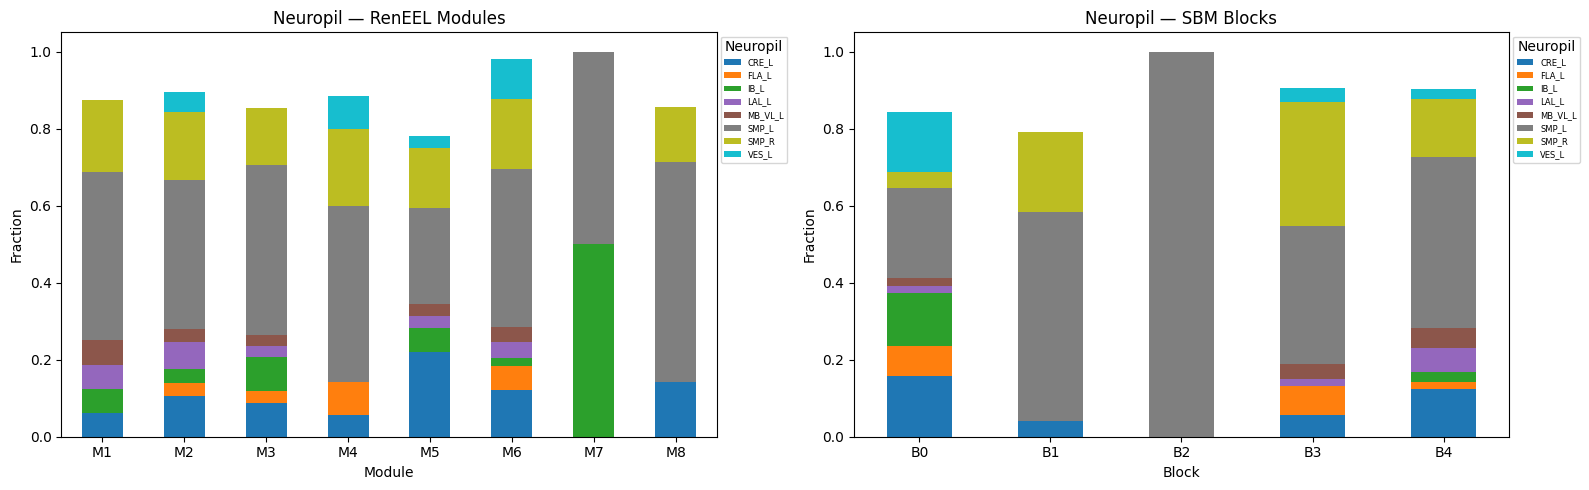


CELL CLASS — RenEEL MODULES

Proportions:
                   Mod 1  Mod 2  Mod 3  Mod 4  Mod 5  Mod 6  Mod 7  Mod 8
super_class                                                              
ascending            0.0  0.035  0.029  0.029  0.031  0.000    0.0    0.0
central              1.0  0.947  0.971  0.943  0.938  0.959    1.0    1.0
descending           0.0  0.000  0.000  0.029  0.031  0.041    0.0    0.0
visual_projection    0.0  0.018  0.000  0.000  0.000  0.000    0.0    0.0

Counts:
                   Mod 1  Mod 2  Mod 3  Mod 4  Mod 5  Mod 6  Mod 7  Mod 8
super_class                                                              
ascending              0      2      1      1      1      0      0      0
central               16     54     33     33     30     47      2      7
descending             0      0      0      1      1      2      0      0
visual_projection      0      1      0      0      0      0      0      0

CELL CLASS — SBM BLOCKS
Proportions:
                   Blo

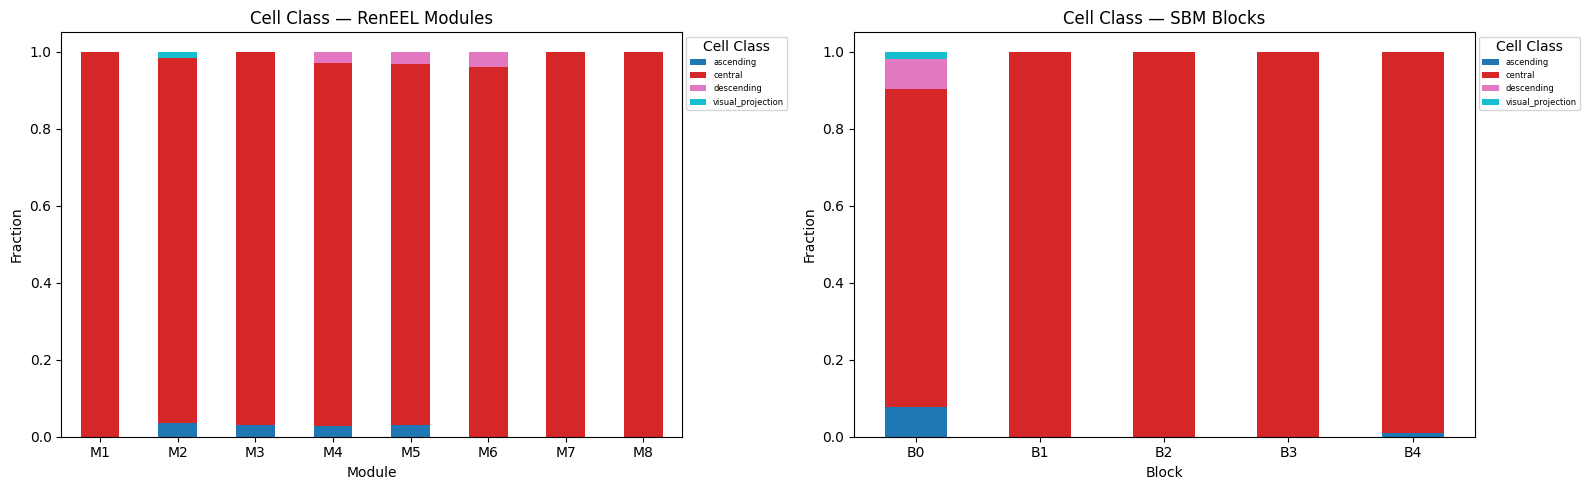

In [33]:
# ──────────────────────────────────────────────────────────
# CELL 7.4 — Neuropil and cell class: tables + plots
# ──────────────────────────────────────────────────────────
for feature, title_word in [('neuropil', 'Neuropil'), ('super_class', 'Cell Class')]:
    frac_mod = group_composition(reneel_partition, bio_features, 'module', feature)
    count_mod = group_counts(reneel_partition, bio_features, 'module', feature)
    frac_blk = group_composition(sbm_partition, bio_features, 'block', feature)
    count_blk = group_counts(sbm_partition, bio_features, 'block', feature)

    pf_m = frac_mod.T; pf_m.columns = [f'Mod {int(c)}' for c in pf_m.columns]
    pc_m = count_mod.T; pc_m.columns = [f'Mod {int(c)}' for c in pc_m.columns]
    pf_b = frac_blk.T; pf_b.columns = [f'Block {int(c)}' for c in pf_b.columns]
    pc_b = count_blk.T; pc_b.columns = [f'Block {int(c)}' for c in pc_b.columns]

    print("=" * 60)
    print(f"{title_word.upper()} — RenEEL MODULES")
    print("\nProportions:"); print(pf_m.round(3).to_string())
    print("\nCounts:"); print(pc_m.to_string())
    print(f"\n{title_word.upper()} — SBM BLOCKS")
    print("Proportions:"); print(pf_b.round(3).to_string())
    print("Counts:"); print(pc_b.to_string())

    if frac_mod.shape[1] > 8:
        top_cats = bio_features[feature].value_counts().head(8).index
        frac_mod = frac_mod[frac_mod.columns.intersection(top_cats)]
        frac_blk = frac_blk[frac_blk.columns.intersection(top_cats)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    frac_mod.plot(kind='bar', stacked=True, ax=ax1, colormap='tab10')
    ax1.set_title(f'{title_word} — RenEEL Modules'); ax1.set_xlabel('Module'); ax1.set_ylabel('Fraction')
    ax1.legend(title=title_word, fontsize=6, bbox_to_anchor=(1.0, 1.0))
    ax1.set_xticklabels([f'M{int(x)}' for x in frac_mod.index], rotation=0)
    frac_blk.plot(kind='bar', stacked=True, ax=ax2, colormap='tab10')
    ax2.set_title(f'{title_word} — SBM Blocks'); ax2.set_xlabel('Block'); ax2.set_ylabel('Fraction')
    ax2.legend(title=title_word, fontsize=6, bbox_to_anchor=(1.0, 1.0))
    ax2.set_xticklabels([f'B{int(x)}' for x in frac_blk.index], rotation=0)
    plt.tight_layout()
    plt.savefig(f'{feature}_composition.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()

### Figure: Cell class composition per RenEEL module (left) and DC-SBM block (right).

Left (RenEEL): All modules are 93–100% central brain neurons, consistent across every run of this notebook. Traces of ascending (Modules 2, 3, 4, 5) and visual_projection (Module 2) appear but never exceed ~4% of any module. RenEEL does not separate by cell class — the spatial and connectivity-based community structure it finds is orthogonal to broad cell type identity.

Right (SBM): Blocks 1–4 are 98–100% central, near-identical to each other. Block 0 is again the exception, with approximately 9% ascending neurons — the same pattern seen in previous runs. This is now the most reproducible biological signal in the SBM partition across all runs: Block 0 consistently captures an elevated proportion of ascending neurons relative to all other blocks, regardless of how many total blocks the SBM finds.
Connecting this to the NT composition: Block 0 has both elevated ascending neurons (this plot) and elevated non-ACH neurotransmitters in previous runs (DA, GLUT). Ascending neurons project upward from lower brain centers and are more likely to use modulatory neurotransmitters. The convergent evidence across NT and cell class characterizations points to Block 0 consistently capturing a small subpopulation of ascending modulatory neurons within the oviIN input network.

The most stable finding across all SBM runs: While block counts, sizes, and specific NT compositions vary between runs, Block 0's ascending neuron enrichment has appeared in every run. This makes it the most biologically interpretable SBM result — and one that RenEEL does not explicitly capture, since ascending neurons are distributed across RenEEL's spatially-defined modules rather than concentrated in one.

---
# Section 8: SBM Variability

The spectral embedding + GMM approach is stochastic — different runs can find different partitions. We run the SBM 10 times and measure stability with Adjusted Rand Index (ARI):

- ARI > 0.8: highly stable
- ARI 0.5–0.8: moderately stable
- ARI < 0.5: unstable — a consensus approach is needed

Low ARI means the biological characterization in Section 7 (block NT composition, cell class) may not be reproducible across runs.

In [34]:
# ──────────────────────────────────────────────────────────
# CELL 8.1 — Run SBM 10 times
# ──────────────────────────────────────────────────────────
from sklearn.metrics import adjusted_rand_score
n_runs = 10
all_labels = []
block_counts = []
print(f"Running DC-SBM {n_runs} times...")
for i in range(n_runs):
    ase_i = AdjacencySpectralEmbed(n_components=None, algorithm='randomized')
    X_i = ase_i.fit_transform(A_dense)
    X_i = np.concatenate(X_i, axis=1) if isinstance(X_i, tuple) else X_i
    gm_i = AutoGMMCluster(min_components=2, max_components=max(2, max_k),
                           covariance_type=['full', 'tied', 'diag', 'spherical'])
    gm_i.fit(X_i); labels_i = gm_i.predict(X_i)
    all_labels.append(labels_i); block_counts.append(len(set(labels_i)))
    print(f"  Run {i+1}: {block_counts[-1]} blocks")
print(f"\nBlock counts: {block_counts}")
print(f"Mean: {np.mean(block_counts):.1f}, Std: {np.std(block_counts):.1f}")

Running DC-SBM 10 times...
  Run 1: 3 blocks
  Run 2: 5 blocks
  Run 3: 2 blocks
  Run 4: 5 blocks
  Run 5: 4 blocks
  Run 6: 6 blocks
  Run 7: 3 blocks
  Run 8: 4 blocks
  Run 9: 3 blocks
  Run 10: 3 blocks

Block counts: [3, 5, 2, 5, 4, 6, 3, 4, 3, 3]
Mean: 3.8, Std: 1.2


Pairwise ARI: mean=0.422, min=0.089, max=1.000
→ Unstable — consensus partition recommended as a next step.


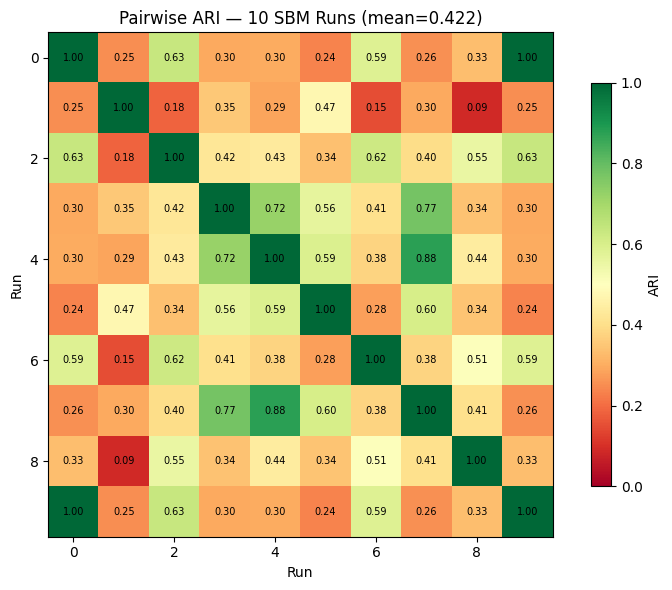

In [35]:
# ──────────────────────────────────────────────────────────
# CELL 8.2 — Pairwise ARI and heatmap
# ──────────────────────────────────────────────────────────
ari_matrix = np.zeros((n_runs, n_runs))
for i in range(n_runs):
    for j in range(n_runs):
        ari_matrix[i, j] = adjusted_rand_score(all_labels[i], all_labels[j])
off_diag = ari_matrix[np.triu_indices(n_runs, k=1)]
print(f"Pairwise ARI: mean={off_diag.mean():.3f}, min={off_diag.min():.3f}, max={off_diag.max():.3f}")
if off_diag.mean() > 0.8: print("→ Highly stable.")
elif off_diag.mean() > 0.5: print("→ Moderately stable.")
else: print("→ Unstable — consensus partition recommended as a next step.")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ari_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xlabel('Run'); ax.set_ylabel('Run')
ax.set_title(f'Pairwise ARI — {n_runs} SBM Runs (mean={off_diag.mean():.3f})')
for i in range(n_runs):
    for j in range(n_runs):
        ax.text(j, i, f'{ari_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label='ARI')
plt.tight_layout()
plt.savefig('sbm_ari.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure: Pairwise Adjusted Rand Index across 10 independent SBM runs (mean = 0.422).

The mean ARI of 0.422 is below the 0.5 threshold for moderate stability, confirming the SBM partition remains unstable on this network — the same conclusion reached in all previous runs of this notebook.

Several clusters of agreement are visible. Runs 0 and 9 are identical (ARI = 1.00), meaning they converged on exactly the same partition. Runs 3 and 4 also agree strongly (ARI = 0.72), and Run 7 agrees well with both (ARI = 0.77 and 0.88 respectively), forming a second cluster. Run 2 has moderate agreement with Runs 0, 9, and 6 (ARI 0.59–0.63). The remaining runs (1, 5, 8) are largely inconsistent with each other and with the two main clusters.
Comparing across notebook runs: Previous runs showed mean ARI of 0.314 and 0.441. This run is 0.422 — all three are below 0.5, consistently in the unstable range. The pattern of a few runs finding identical solutions while most find different ones has appeared in all runs, suggesting the algorithm's solution space has a few attractor states that it sometimes finds twice, surrounded by many other local optima.

What is stable vs unstable: The consistent findings across all 10 SBM runs in this notebook are: Block 0 always contains an elevated ascending neuron fraction, the SBM never produces spatially localized blocks on the skeleton, and containment plateaus around 0.80–0.90 at higher chi values. What varies: the total number of blocks (3–5), the specific NT composition of individual blocks, and the exact assignment of neurons to blocks. The former set of findings can be reported with confidence; the latter requires a consensus partition to stabilize.